# Fibrilação Atrial em ECGs de Longa Duração

- Pedro Paulo Camargo
- Henrique Badin

## 1. Preparação do Ambiente

In [ ]:
import sys
import subprocess

subprocess.check_call([
    sys.executable, '-m', 'pip', 'install', '-r', 'requirements.txt'
])

# Imports
from pathlib import Path
from collections import defaultdict
import textwrap
import warnings

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets

from IPython.display import display, clear_output
from scipy.signal import find_peaks

from scipy.signal import butter, filtfilt
from scipy.stats import iqr
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from IPython.display import display

# Configurações de visualização e limpeza de warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)


## 2. Visão Geral da Base de ECGs

### 2.1 Registros Disponíveis

Nesta etapa, o notebook localiza automaticamente os arquivos WFDB válidos na pasta `data/` e monta uma visão inicial dos registros que poderão ser analisados.

In [2]:
# Configurações centrais da análise
# DATA_DIR: pasta onde estão os registros WFDB (.hea/.dat/.atr)
# SELECTED_RECORD_INDEX: índice do exame escolhido para análise detalhada
# WINDOW_SECONDS: duração padrão das janelas exibidas nos navegadores interativos
DATA_DIR = Path('data')
ANNOTATION_EXTENSION = 'atr'
SELECTED_RECORD_INDEX = 0
WINDOW_SECONDS = 5


In [4]:
# ============================================================
# Funções auxiliares de leitura, limpeza e sumarização da base
# ============================================================

def list_wfdb_records(data_dir: Path):
    """Lista automaticamente os registros WFDB válidos na pasta informada."""
    hea_files = sorted(data_dir.rglob('*.hea'))
    records = []
    seen = set()

    for hea_file in hea_files:
        record_base = hea_file.with_suffix('')
        dat_file = record_base.with_suffix('.dat')

        if dat_file.exists() and str(record_base) not in seen:
            records.append(record_base)
            seen.add(str(record_base))

    return records


def clean_note(note):
    """Remove caracteres nulos e espaços extras das anotações."""
    return str(note).replace('\x00', '').strip()


def has_annotation(record_path: Path, extension: str = ANNOTATION_EXTENSION):
    """Verifica se o registro possui o arquivo de anotação esperado."""
    return record_path.with_suffix(f'.{extension}').exists()


def load_record(record_path: Path, annotation_extension: str = ANNOTATION_EXTENSION):
    """Carrega o sinal e, se existir, as anotações do registro."""
    record = wfdb.rdrecord(str(record_path))
    annotations = None

    if has_annotation(record_path, annotation_extension):
        annotations = wfdb.rdann(str(record_path), annotation_extension)

    return record, annotations


def get_rhythm_indices(annotations):
    """Retorna apenas os índices das anotações que representam mudança explícita de ritmo."""
    if annotations is None:
        return []

    rhythm_indices = []
    for i, note in enumerate(annotations.aux_note):
        note = clean_note(note)
        if note.startswith('('):
            rhythm_indices.append(i)

    return rhythm_indices


def summarize_rhythms(record, annotations):
    """Agrupa contagem e tempo total por ritmo para um registro."""
    stats = {}
    timeline = []
    rhythm_indices = get_rhythm_indices(annotations)

    for position, current_idx in enumerate(rhythm_indices):
        rhythm_name = clean_note(annotations.aux_note[current_idx]).replace('(', '')
        start_sample = int(annotations.sample[current_idx])

        # O fim do ritmo atual é definido pela próxima anotação de mudança
        if position + 1 < len(rhythm_indices):
            end_sample = int(annotations.sample[rhythm_indices[position + 1]])
        else:
            end_sample = int(record.sig_len)

        duration_seconds = (end_sample - start_sample) / record.fs

        if rhythm_name not in stats:
            stats[rhythm_name] = {'contagem': 0, 'tempo_total_s': 0.0}

        stats[rhythm_name]['contagem'] += 1
        stats[rhythm_name]['tempo_total_s'] += duration_seconds
        timeline.append(f'{rhythm_name} ({duration_seconds:.1f}s)')

    return stats, timeline


def signal_dataframe(record):
    """Converte o sinal para DataFrame, independentemente do número de canais."""
    column_names = [f'Canal_{i + 1}' for i in range(record.n_sig)]
    return pd.DataFrame(record.p_signal, columns=column_names)


def find_flatlines(signal_column, sampling_frequency, limit_seconds=2):
    """Encontra trechos com valor 0.0 contínuo por pelo menos `limit_seconds`."""
    series = pd.Series(signal_column)
    is_zero = series.eq(0.0)
    blocks = is_zero.ne(is_zero.shift()).cumsum()
    block_sizes = is_zero.groupby(blocks).sum()

    minimum_samples = int(limit_seconds * sampling_frequency)
    real_flatlines = block_sizes[block_sizes >= minimum_samples]

    event_count = int(len(real_flatlines))
    total_time_seconds = float(real_flatlines.sum() / sampling_frequency)

    return event_count, total_time_seconds


def extract_afib_episodes(record, annotations):
    """Extrai tabela com episódios de AFIB para um registro."""
    if annotations is None:
        return pd.DataFrame()

    episodes = []
    rhythm_indices = [i for i, note in enumerate(annotations.aux_note) if clean_note(note) != '']

    for position, current_idx in enumerate(rhythm_indices):
        current_note = clean_note(annotations.aux_note[current_idx])

        if '(AFIB' not in current_note:
            continue

        start_sample = int(annotations.sample[current_idx])

        # O episódio termina quando uma nova anotação de ritmo aparece
        if position + 1 < len(rhythm_indices):
            next_idx = rhythm_indices[position + 1]
            end_sample = int(annotations.sample[next_idx])
            next_rhythm = clean_note(annotations.aux_note[next_idx]).replace('(', '')
        else:
            end_sample = int(record.sig_len)
            next_rhythm = 'FIM DO EXAME'

        duration_seconds = (end_sample - start_sample) / record.fs
        duration_minutes = duration_seconds / 60

        episodes.append({
            'Início (s)': round(start_sample / record.fs, 2),
            'Fim (s)': round(end_sample / record.fs, 2),
            'Duração (s)': round(duration_seconds, 2),
            'Duração (min)': round(duration_minutes, 2),
            'Terminou em': next_rhythm
        })

    return pd.DataFrame(episodes)


def detect_r_peaks(signal, sampling_frequency, min_distance_seconds=0.25):
    """Detecta picos R tentando automaticamente as duas polaridades do sinal."""
    if len(signal) == 0:
        return np.array([], dtype=int), 1

    # A distância mínima entre picos evita contagens irreais em alta frequência.
    distance = max(1, int(min_distance_seconds * sampling_frequency))
    threshold = max(0.20 * np.nanstd(signal), 0.05)
    prominence = max(0.10 * np.nanstd(signal), 0.02)

    pos_idx, _ = find_peaks(signal, height=threshold, distance=distance, prominence=prominence)
    neg_idx, _ = find_peaks(-signal, height=threshold, distance=distance, prominence=prominence)

    def score(indices):
        if len(indices) == 0:
            return -np.inf
        mean_amplitude = np.mean(np.abs(signal[indices]))
        if len(indices) == 1:
            return mean_amplitude
        rr = np.diff(indices) / sampling_frequency

        # Favorece séries de RR fisiologicamente plausíveis para reduzir detecções espúrias.
        plausible_rr = np.mean((rr >= 60 / 220) & (rr <= 60 / 35))
        return mean_amplitude + plausible_rr

    if score(neg_idx) > score(pos_idx):
        return neg_idx, -1
    return pos_idx, 1


def first_index_matching(annotations, token):
    """Retorna o primeiro índice de anotação que contenha o token informado."""
    if annotations is None:
        return None
    for i, note in enumerate(annotations.aux_note):
        if token in clean_note(note):
            return i
    return None


def find_normal_to_afib_transition(annotations):
    """Procura a primeira transição explícita de ritmo normal para AFIB."""
    if annotations is None:
        return None, None

    rhythm_indices = get_rhythm_indices(annotations)
    for i in range(len(rhythm_indices) - 1):
        current_note = clean_note(annotations.aux_note[rhythm_indices[i]])
        next_note = clean_note(annotations.aux_note[rhythm_indices[i + 1]])

        if '(N' in current_note and '(AFIB' in next_note:
            return rhythm_indices[i], rhythm_indices[i + 1]

    return None, None


# ============================================================
# Montagem do catálogo inicial de registros disponíveis
# ============================================================
record_paths = list_wfdb_records(DATA_DIR)

if not record_paths:
    raise FileNotFoundError(
        f'Nenhum registro WFDB válido foi encontrado em {DATA_DIR.resolve()}. '
        'Verifique se a pasta existe e contém pares .hea/.dat.'
    )

record_catalog = pd.DataFrame({
    'Índice': range(len(record_paths)),
    'Registro': [path.name for path in record_paths],
    'Caminho base': [str(path) for path in record_paths],
    'Tem .atr?': [has_annotation(path) for path in record_paths],
})

print(f'Total de registros encontrados em "{DATA_DIR}": {len(record_paths)}')
records_with_annotation = [p for p in record_paths if has_annotation(p)]
print(f'Total de registros encontrados com anotações em "{DATA_DIR}": {len(records_with_annotation)}')
display(record_catalog.head(10).style.hide(axis="index"))

Total de registros encontrados em "data": 84
Total de registros encontrados com anotações em "data": 84


Índice,Registro,Caminho base,Tem .atr?
0,00,data\00,True
1,01,data\01,True
2,03,data\03,True
3,05,data\05,True
4,06,data\06,True
5,07,data\07,True
6,08,data\08,True
7,10,data\10,True
8,100,data\100,True
9,101,data\101,True


### 2.2 Resumo Registros da Pasta

Aqui é gerado um painel comparativo com duração, presença de anotações, episódios de AFIB, eventos de ruído e indícios de flatline para todos os exames encontrados.

In [5]:
# Consolidação global de todos os exames da pasta
# Para cada registro, são resumidos canais, duração, AFIB, ruído e possíveis flatlines.
all_record_rows = []
global_rhythm_stats = defaultdict(lambda: {'episodios': 0, 'tempo_total_s': 0.0})

for record_path in record_paths:
    try:
        record, annotations = load_record(record_path)

        rhythm_stats, _ = summarize_rhythms(record, annotations)

        # AFIB 
        has_afib = annotations is not None and any(
            '(AFIB' in clean_note(n) for n in annotations.aux_note
        )
        afib_df = extract_afib_episodes(record, annotations) if has_afib else pd.DataFrame()

        # Flatlines
        flatline_summary = {}
        for i in range(record.n_sig):
            signal_column = record.p_signal[:, i]
            events, total_time = find_flatlines(signal_column, record.fs)

            flatline_summary[f'Canal_{i+1}_eventos'] = events
            flatline_summary[f'Canal_{i+1}_tempo_s'] = total_time

        # Ruído
        noise_count = 0
        if annotations is not None:
            noise_count = sum(1 for s in annotations.symbol if s == "|")

        # AFIB ratio
        total_duration_min = record.sig_len / record.fs / 60
        afib_time = afib_df['Duração (min)'].sum() if not afib_df.empty else 0
        afib_ratio = afib_time / total_duration_min if total_duration_min > 0 else 0

        # Global stats
        for rhythm_name, values in rhythm_stats.items():
            global_rhythm_stats[rhythm_name]['episodios'] += values['contagem']
            global_rhythm_stats[rhythm_name]['tempo_total_s'] += values['tempo_total_s']

        all_record_rows.append({
            'Registro': record_path.name,
            'Canais': record.n_sig,
            'Frequência (Hz)': record.fs,
            'Duração (min)': round(total_duration_min, 2),
            'Tem anotação': annotations is not None,
            'Episódios AFIB': len(afib_df),
            'Tempo total AFIB (min)': round(afib_time, 2),
            '% Tempo AFIB': round(afib_ratio * 100, 2),
            'Eventos de ruído': noise_count,
            'Ritmos detectados': ', '.join(sorted(rhythm_stats.keys())) if rhythm_stats else 'Nenhum',
            **flatline_summary,
        })

    except Exception as e:
        print(f'Erro no registro {record_path.name}: {e}')


In [ ]:
summary_df = pd.DataFrame(all_record_rows)

# Flags úteis
summary_df['AFIB Presente'] = summary_df['% Tempo AFIB'] > 0
summary_df['Sinal Ruim'] = summary_df['Eventos de ruído'] > 0

main_columns = [
    'Registro', 'Canais', 'Frequência (Hz)', 'Duração (min)',
    'Episódios AFIB', 'Tempo total AFIB (min)', '% Tempo AFIB',
    'Eventos de ruído', 'Ritmos detectados'
]

print('=== VISÃO GERAL DOS REGISTROS ===')

display(
    summary_df[main_columns]
    .sort_values('% Tempo AFIB', ascending=False)
    .style
    .hide(axis="index")
    .format({
        'Duração (min)': '{:.1f}',
        'Tempo total AFIB (min)': '{:.1f}',
        '% Tempo AFIB': '{:.1f}%'
    })
    .background_gradient(subset=['% Tempo AFIB'], cmap='Reds')
)

=== VISÃO GERAL DOS REGISTROS ===


Registro,Canais,Frequência (Hz),Duração (min),Episódios AFIB,Tempo total AFIB (min),% Tempo AFIB,Eventos de ruído,Ritmos detectados
33,2,128,1465.0,120,1440.0,98.3%,0,"AFIB, B, T, VT"
204,2,128,1257.0,334,1234.2,98.2%,0,"AFIB, VT"
25,2,128,1100.0,346,1066.5,97.0%,0,"AFIB, IVR, VT"
68,2,128,1440.0,6,1381.3,95.9%,0,"AFIB, VT"
200,2,128,1433.0,19,1358.5,94.8%,0,"AFIB, N, T, VT"
203,2,128,1090.0,6,1010.7,92.7%,0,"AFIB, IVR, VT"
26,2,128,1101.0,177,995.5,90.4%,0,"AB, AFIB, N, SBR, SVTA, T"
39,2,128,1500.0,141,1232.9,82.2%,0,"AB, AFIB, N, SBR, SVTA"
206,2,128,1258.0,6,1028.8,81.8%,0,"AFIB, SBR, VT"
15,2,128,1475.0,801,1141.6,77.4%,0,"AFIB, N, SBR"


In [10]:
flatline_rows = []

for row in all_record_rows:
    for key, value in row.items():
        if '_eventos' in key:
            canal = key.replace('_eventos', '')
            tempo_key = f'{canal}_tempo_s'

            flatline_rows.append({
                'Registro': row['Registro'],
                'Canal': canal,
                'Eventos': value,
                'Tempo (s)': row.get(tempo_key, 0)
            })

flatline_df = pd.DataFrame(flatline_rows)

registros_com_flatline = flatline_df[flatline_df['Eventos'] > 0]['Registro'].nunique()

In [11]:
total_records = len(summary_df)
afib_records = (summary_df['% Tempo AFIB'] > 0).sum()
noise_records = (summary_df['Eventos de ruído'] > 0).sum()
flatline_records = flatline_df['Registro'].nunique() if not flatline_df.empty else 0

print(f'Total de registros: {total_records}')
print(f'Com AFIB: {afib_records}')
print(f'Com ruído: {noise_records}')
print(f'Com flatline: {registros_com_flatline}')


Total de registros: 84
Com AFIB: 83
Com ruído: 0
Com flatline: 0


In [14]:
print('\n=== CONSOLIDADO GLOBAL DOS RITMOS ===')
global_rhythm_df = pd.DataFrame([
    {
        'Ritmo': rhythm_name,
        'Episódios': values['episodios'],
        'Tempo total (min)': round(values['tempo_total_s'] / 60, 2)
    }
    for rhythm_name, values in global_rhythm_stats.items()
])

if global_rhythm_df.empty:
    print('Nenhuma mudança de ritmo explícita encontrada.')
else:
    display(
        global_rhythm_df
        .sort_values(['Tempo total (min)', 'Episódios'], ascending=False)
        .style
        .hide(axis="index")
        .format({'Tempo total (min)': '{:.1f}'})
        .background_gradient(subset=['Tempo total (min)'], cmap='Blues')
    )


=== CONSOLIDADO GLOBAL DOS RITMOS ===


Ritmo,Episódios,Tempo total (min)
AFIB,7358,61853.6
N,22834,49712.9
SBR,11326,3334.9
AB,4472,579.5
B,2696,280.2
SVTA,3268,199.6
T,785,102.6
VT,828,24.3
IVR,137,7.7


## 3. Análise Detalhada do Registro Selecionado

A partir deste ponto, o notebook sai da visão global da base e aprofunda a investigação em **um único exame**, definido por `SELECTED_RECORD_INDEX`.

### 3.1 Contexto e metadados do registro selecionado

Resume os principais metadados do exame escolhido e exibe uma amostra inicial do sinal para contextualizar as etapas seguintes.

In [24]:
if SELECTED_RECORD_INDEX >= len(record_paths):
    raise IndexError(
        f'SELECTED_RECORD_INDEX={SELECTED_RECORD_INDEX} inválido para {len(record_paths)} registros.'
    )

selected_record_path = record_paths[SELECTED_RECORD_INDEX]
record, annotations = load_record(selected_record_path)

plot_channel = 1 if record.n_sig > 1 else 0

duration_hours = record.sig_len / record.fs / 3600

# RESUMO DO REGISTRO
print('\n' + '='*60)
print('RESUMO DO REGISTRO')
print('='*60)

print(f'Registro        : {selected_record_path.name}')
print(f'Canais          : {record.n_sig}')
print(f'Frequência      : {record.fs} Hz')
print(f'Duração         : {duration_hours:.2f} h')
print(f'Canal padrão    : Canal_{plot_channel + 1}')
print(f'Anotação        : {"Sim" if annotations else "Não"}')
df_signal = signal_dataframe(record)

print('\n[Preview do sinal]')
display(df_signal.head())


RESUMO DO REGISTRO
Registro        : 00
Canais          : 2
Frequência      : 128 Hz
Duração         : 20.97 h
Canal padrão    : Canal_2
Anotação        : Sim

[Preview do sinal]


,Canal_1,Canal_2
0,-0.00599,0.01734
1,-0.01198,0.02312
2,0.00599,0.01734
3,0.00000,0.01734
4,-0.01198,0.01734


### 3.2 Estatísticas descritivas e checagem de qualidade do sinal

Nesta etapa, avaliamos a distribuição dos sinais, a presença de valores ausentes, trechos de flatline e marcações de ruído nas anotações.

In [ ]:
# ESTATÍSTICAS
print('\n' + '-'*60)
print('ESTATÍSTICAS DOS SINAIS (mV)')
print('-'*60)

display(df_signal.describe())

# INTEGRIDADE
nan_counts = df_signal.isna().sum()

print('\n[Valores ausentes]')
print(nan_counts.to_string())

# FLATLINES
print('\n' + '-'*60)
print('FLATLINES (>2s)')
print('-'*60)

flatline_total = 0

for i in range(record.n_sig):
    signal_column = record.p_signal[:, i]
    events, total_time = find_flatlines(signal_column, record.fs)

    flatline_total += events

    if events > 0:
        print(f'Canal_{i+1}: {events} evento(s) | {total_time:.1f}s')

if flatline_total == 0:
    print('Nenhum flatline detectado.')

# RUÍDO
print('\n' + '-'*60)
print('RUÍDO (anotações "|")')
print('-'*60)

if annotations is None:
    print('Sem arquivo de anotação.')
else:
    noise_count = sum(1 for s in annotations.symbol if s == "|")

    if noise_count > 0:
        print(f'{noise_count} evento(s) de ruído extremo detectado(s)')
    else:
        print('Nenhum ruído extremo anotado.')


------------------------------------------------------------
ESTATÍSTICAS DOS SINAIS (mV)
------------------------------------------------------------


,Canal_1,Canal_2
count,9.661440e+06,9.661440e+06
mean,-4.068252e-03,8.943039e-03
std,1.359463e-01,3.234250e-01
min,-4.714127e+00,-5.144211e+00
25%,-7.786996e-02,5.780013e-03
50%,-1.197999e-02,5.780013e-02
75%,5.390997e-02,1.213803e-01
max,3.785678e+00,2.392925e+00



[Valores ausentes]
Canal_1    0
Canal_2    0

------------------------------------------------------------
FLATLINES (>2s)
------------------------------------------------------------
Nenhum flatline detectado.

------------------------------------------------------------
RUÍDO (anotações "|")
------------------------------------------------------------
Nenhum ruído extremo anotado.


### 3.3 Linha do tempo dos ritmos anotados

Aqui é montado um resumo textual das mudanças de ritmo anotadas ao longo do exame selecionado, permitindo entender a sequência e a duração relativa de cada padrão identificado.

In [27]:
# RITMOS
rhythm_stats, timeline = summarize_rhythms(record, annotations)

print('\n' + '='*60)
print('RITMOS DETECTADOS')
print('='*60)

if not rhythm_stats:
    print('Nenhuma mudança de ritmo detectada.')
else:
    total_time = 0

    for rhythm, values in sorted(rhythm_stats.items()):
        t = values['tempo_total_s']
        total_time += t

        print(
            f'{rhythm:<10} | episódios: {values["contagem"]:>3} '
            f'| tempo: {t/60:.1f} min'
        )

    print('-'*60)
    print(f'Tempo total analisado: {total_time/60:.1f} min')


# TIMELINE (RESUMIDA)
if timeline:
    print('\n[Timeline simplificada]')
    print(' -> '.join(timeline[:10]) + (' ...' if len(timeline) > 10 else ''))


RITMOS DETECTADOS
AFIB       | episódios:  44 | tempo: 134.9 min
N          | episódios:   5 | tempo: 1111.5 min
VT         | episódios:  40 | tempo: 0.7 min
------------------------------------------------------------
Tempo total analisado: 1247.1 min

[Timeline simplificada]
N (35386.3s) -> AFIB (34.6s) -> VT (1.1s) -> AFIB (179.9s) -> N (241.0s) -> AFIB (99.9s) -> N (204.9s) -> AFIB (9.6s) -> VT (1.1s) -> AFIB (49.8s) ...


### 3.4 Navegação por episódios anotados de AFIB

A visualização abaixo permite percorrer diferentes trechos anotados como fibrilação atrial e comparar sua morfologia em cada canal disponível.

In [28]:
# Localiza todas as entradas anotadas como AFIB para permitir navegação interativa entre janelas.
indices_afib = [] if annotations is None else [
    i for i, note in enumerate(annotations.aux_note) if '(AFIB' in clean_note(note)
]


class RhythmNavigator:
    """Componente interativo para percorrer janelas temporais anotadas com um ritmo específico."""

    def __init__(self, record, annotations, indices, title_prefix, first_color='#d62728'):
        self.record = record
        self.annotations = annotations
        self.indices = indices
        self.title_prefix = title_prefix
        self.first_color = first_color
        self.current_index = 0
        self.window_seconds = WINDOW_SECONDS

        if not self.indices:
            print(f'Nenhum trecho correspondente a "{title_prefix}" foi encontrado neste registro.')
            return

        self.btn_prev = widgets.Button(description='⬅️ Anterior', layout=widgets.Layout(width='150px'))
        self.btn_next = widgets.Button(description='Próximo ➡️', layout=widgets.Layout(width='150px'))
        self.output = widgets.Output()

        self.btn_prev.on_click(self.previous)
        self.btn_next.on_click(self.next)

        display(widgets.HBox([self.btn_prev, self.btn_next]), self.output)
        self.render()

    def render(self):
        with self.output:
            clear_output(wait=True)

            annotation_index = self.indices[self.current_index]
            start_sample = int(self.annotations.sample[annotation_index])
            n_samples = int(self.window_seconds * self.record.fs)
            end_sample = min(start_sample + n_samples, self.record.sig_len)

            relative_time = np.linspace(0, (end_sample - start_sample) / self.record.fs, end_sample - start_sample)
            signals = self.record.p_signal[start_sample:end_sample]

            fig, axes = plt.subplots(self.record.n_sig, 1, figsize=(15, 4 * self.record.n_sig), sharex=True)
            if self.record.n_sig == 1:
                axes = [axes]

            for channel_idx, ax in enumerate(axes):
                color = self.first_color if channel_idx == 0 else '#1f77b4'
                ax.plot(relative_time, signals[:, channel_idx], color=color, lw=1.2)
                ax.set_title(
                    f'{self.title_prefix} | Janela {self.current_index + 1} de {len(self.indices)} | '
                    f'Início real: {start_sample / self.record.fs:.2f}s | Canal {channel_idx + 1}'
                )
                ax.set_ylabel('Amplitude (mV)')
                ax.grid(True, alpha=0.3)

            axes[-1].set_xlabel('Tempo dentro da janela (s)')
            plt.suptitle(
                f'Inspeção de trechos anotados | Registro: {selected_record_path.name}',
                fontsize=15,
                fontweight='bold'
            )
            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            plt.show()

    def next(self, _):
        if self.current_index < len(self.indices) - 1:
            self.current_index += 1
            self.render()

    def previous(self, _):
        if self.current_index > 0:
            self.current_index -= 1
            self.render()


navegador_afib = RhythmNavigator(
    record=record,
    annotations=annotations,
    indices=indices_afib,
    title_prefix='Trecho anotado como AFIB',
    first_color='#d62728'
)


Output()

### 3.5 Navegação por trechos em ritmo normal

Esta subseção funciona como contraponto visual à etapa anterior, permitindo comparar janelas anotadas como ritmo normal.

In [29]:
# Seleciona até 10 trechos em ritmo normal para comparação visual com os episódios de AFIB.
indices_normais = [] if annotations is None else [
    i for i, note in enumerate(annotations.aux_note) if '(N' in clean_note(note)
][:10]

navegador_normal = RhythmNavigator(
    record=record,
    annotations=annotations,
    indices=indices_normais,
    title_prefix='Trecho anotado como ritmo normal',
    first_color='#2ca02c'
)


Output()

### 3.6 Tabela-Resumo dos episódios de AFIB

A tabela a seguir resume os episódios de fibrilação atrial encontrados no registro selecionado, incluindo início, fim, duração e o ritmo subsequente.

In [36]:
# Gera uma tabela estruturada apenas com os episódios de fibrilação atrial do registro selecionado.
df_afib = extract_afib_episodes(record, annotations)

if df_afib.empty:
    print('Nenhum episódio de AFIB foi encontrado neste registro.')
else:
    print('-' * 50)
    print(f'Episódio mais curto: {df_afib["Duração (s)"].min()} segundos')
    print(f'Episódio mais longo: {df_afib["Duração (min)"].max()} minutos')
    print(f'Tempo médio em AFIB: {df_afib["Duração (s)"].mean():.2f} segundos')
    print('-' * 50)
    display(df_afib)


--------------------------------------------------
Episódio mais curto: 1.47 segundos
Episódio mais longo: 18.8 minutos
Tempo médio em AFIB: 183.96 segundos
--------------------------------------------------


,Início (s),Fim (s),Duração (s),Duração (min),Terminou em
0,36039.45,36074.04,34.59,0.58,VT
1,36075.16,36255.01,179.85,3.00,N
2,36496.05,36595.90,99.85,1.66,N
3,36800.77,36810.39,9.62,0.16,VT
4,36811.53,36861.37,49.84,0.83,VT
5,36862.26,36878.56,16.30,0.27,VT
6,36879.56,36910.47,30.91,0.52,VT
7,36911.39,36946.08,34.69,0.58,N
8,37312.45,37313.92,1.47,0.02,VT
9,37315.27,37354.77,39.51,0.66,VT


### 3.7 Comparação automática na transição de ritmo normal para AFIB

Nesta etapa, o notebook tenta localizar automaticamente a primeira transição explícita de ritmo normal para AFIB e compara os dois lados dessa mudança.

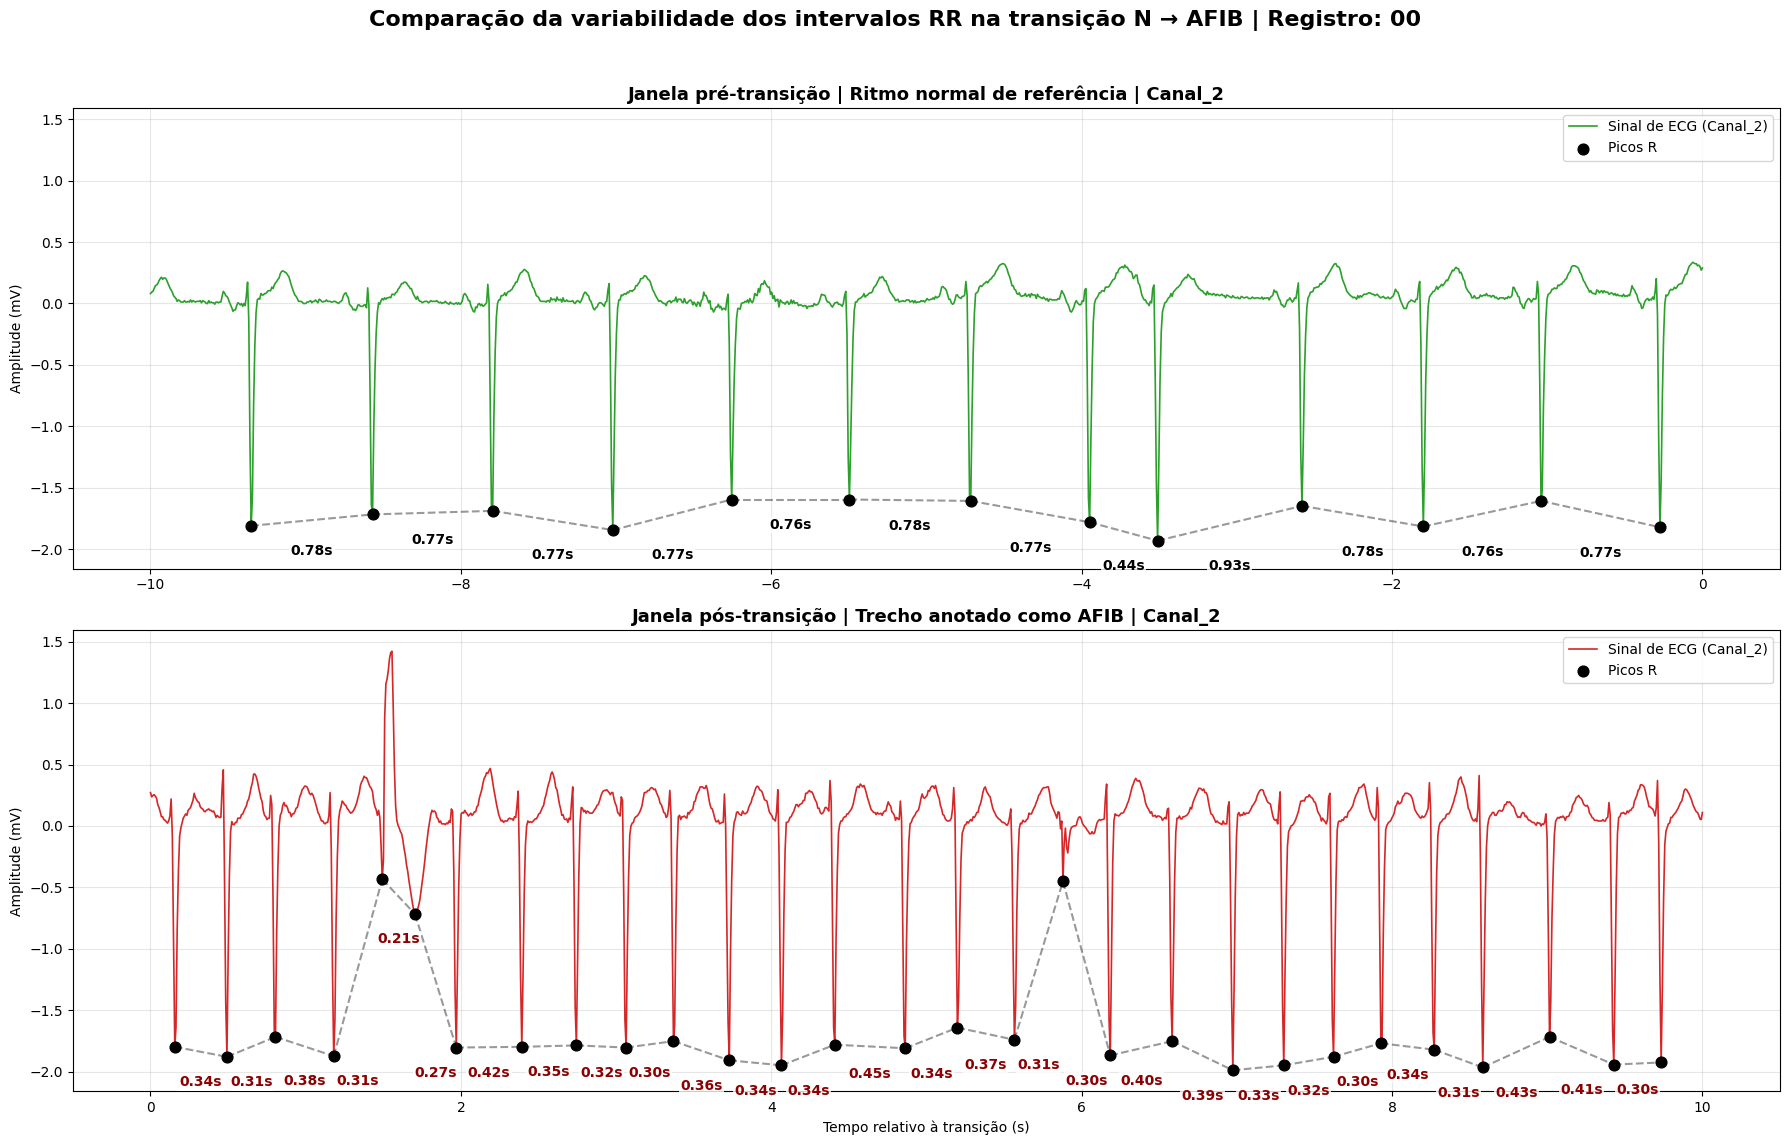

In [37]:
# Procura a primeira transição explícita N -> AFIB para comparar a regularidade dos intervalos RR.
normal_idx, afib_idx = find_normal_to_afib_transition(annotations)

if afib_idx is None:
    print('Nenhuma transição explícita de ritmo normal para AFIB foi encontrada neste registro.')
else:
    transition_sample = int(annotations.sample[afib_idx])
    sampling_frequency = record.fs
    channel_name = f'Canal_{plot_channel + 1}'

    # Janela imediatamente anterior à transição: usada como referência de ritmo normal.
    start_normal = max(0, transition_sample - int(10 * sampling_frequency))
    end_normal = transition_sample
    signal_normal = record.p_signal[start_normal:end_normal, plot_channel]
    time_normal = np.linspace(-len(signal_normal) / sampling_frequency, 0, len(signal_normal))

    # Janela imediatamente posterior à transição: usada como exemplo de AFIB.
    start_afib = transition_sample
    end_afib = min(record.sig_len, transition_sample + int(10 * sampling_frequency))
    signal_afib = record.p_signal[start_afib:end_afib, plot_channel]
    time_afib = np.linspace(0, len(signal_afib) / sampling_frequency, len(signal_afib))

    # Detecta picos R e deriva intervalos RR para evidenciar a diferença de regularidade.
    peaks_normal_idx, _ = detect_r_peaks(signal_normal, sampling_frequency, min_distance_seconds=0.30)
    peaks_afib_idx, _ = detect_r_peaks(signal_afib, sampling_frequency, min_distance_seconds=0.20)

    time_peaks_normal = time_normal[peaks_normal_idx] if len(peaks_normal_idx) else np.array([])
    values_peaks_normal = signal_normal[peaks_normal_idx] if len(peaks_normal_idx) else np.array([])
    time_peaks_afib = time_afib[peaks_afib_idx] if len(peaks_afib_idx) else np.array([])
    values_peaks_afib = signal_afib[peaks_afib_idx] if len(peaks_afib_idx) else np.array([])

    rr_normal = np.diff(time_peaks_normal) if len(time_peaks_normal) > 1 else np.array([])
    rr_afib = np.diff(time_peaks_afib) if len(time_peaks_afib) > 1 else np.array([])

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 12), sharey=True)

    ax1.plot(time_normal, signal_normal, color='#2ca02c', lw=1.2, label=f'Sinal de ECG ({channel_name})')
    if len(time_peaks_normal):
        ax1.scatter(time_peaks_normal, values_peaks_normal, color='black', s=60, zorder=5, label='Picos R')

    for i in range(len(rr_normal)):
        x_mid = time_peaks_normal[i] + rr_normal[i] / 2
        y_pos = min(values_peaks_normal[i], values_peaks_normal[i + 1]) - 0.15
        ax1.plot(
            [time_peaks_normal[i], time_peaks_normal[i + 1]],
            [values_peaks_normal[i], values_peaks_normal[i + 1]],
            color='black',
            linestyle='--',
            alpha=0.4
        )
        ax1.text(
            x_mid, y_pos, f'{rr_normal[i]:.2f}s',
            ha='center', va='top',
            fontsize=10, color='black', fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1)
        )

    ax1.set_title(f'Janela pré-transição | Ritmo normal de referência | {channel_name}', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Amplitude (mV)')
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper right')

    ax2.plot(time_afib, signal_afib, color='#d62728', lw=1.2, label=f'Sinal de ECG ({channel_name})')
    if len(time_peaks_afib):
        ax2.scatter(time_peaks_afib, values_peaks_afib, color='black', s=60, zorder=5, label='Picos R')

    for i in range(len(rr_afib)):
        x_mid = time_peaks_afib[i] + rr_afib[i] / 2
        y_pos = min(values_peaks_afib[i], values_peaks_afib[i + 1]) - 0.15
        ax2.plot(
            [time_peaks_afib[i], time_peaks_afib[i + 1]],
            [values_peaks_afib[i], values_peaks_afib[i + 1]],
            color='black',
            linestyle='--',
            alpha=0.4
        )
        ax2.text(
            x_mid, y_pos, f'{rr_afib[i]:.2f}s',
            ha='center', va='top',
            fontsize=10, color='darkred', fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1)
        )

    ax2.set_title(f'Janela pós-transição | Trecho anotado como AFIB | {channel_name}', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Tempo relativo à transição (s)')
    ax2.set_ylabel('Amplitude (mV)')
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='upper right')

    plt.suptitle(
        f'Comparação da variabilidade dos intervalos RR na transição N → AFIB | Registro: {selected_record_path.name}',
        fontsize=16,
        fontweight='bold'
    )
    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.show()


### 3.8 Comparação evolutiva por fases

Esta visualização compara janelas sucessivas de um trecho normal e de um trecho em AFIB dentro do mesmo registro.

Assim como na etapa anterior, o código evita depender de amostras fixas e tenta localizar automaticamente trechos compatíveis nas anotações, permitindo observar a persistência ou a variação do padrão ao longo do tempo.

In [38]:
# Busca automaticamente um trecho normal e um trecho AFIB para comparação evolutiva em múltiplas fases.
normal_start_idx = first_index_matching(annotations, '(N')
afib_start_idx = first_index_matching(annotations, '(AFIB')
phase_window_seconds = 10
total_phases = 4


class PhaseComparator:
    """Navegador para comparar, fase a fase, janelas normais e janelas AFIB."""

    def __init__(
        self,
        record,
        normal_start_sample,
        afib_start_sample,
        plot_channel,
        phase_window_seconds=10,
        total_phases=4
    ):
        self.record = record
        self.normal_start_sample = normal_start_sample
        self.afib_start_sample = afib_start_sample
        self.plot_channel = plot_channel
        self.phase_window_seconds = phase_window_seconds
        self.total_phases = total_phases
        self.current_phase = 0

        if self.normal_start_sample is None or self.afib_start_sample is None:
            print('Não foi possível montar a comparação em fases: faltam trechos normal ou AFIB nas anotações.')
            return

        self.btn_prev = widgets.Button(description='⬅️ Fase Anterior', layout=widgets.Layout(width='180px'))
        self.btn_next = widgets.Button(description='Próxima Fase ➡️', layout=widgets.Layout(width='180px'))
        self.output = widgets.Output()

        self.btn_prev.on_click(self.previous)
        self.btn_next.on_click(self.next)

        display(widgets.HBox([self.btn_prev, self.btn_next]), self.output)
        self.render()

    def plot_signal(self, ax, base_sample, color, title, is_afib=False):
        # Cada fase representa uma janela sucessiva deslocada no tempo.
        start_sample = base_sample + int(self.current_phase * self.phase_window_seconds * self.record.fs)
        end_sample = min(self.record.sig_len, start_sample + int(self.phase_window_seconds * self.record.fs))

        signal = self.record.p_signal[start_sample:end_sample, self.plot_channel]
        time_axis = np.linspace(
            self.current_phase * self.phase_window_seconds,
            self.current_phase * self.phase_window_seconds + len(signal) / self.record.fs,
            len(signal)
        )

        peak_distance = 0.20 if is_afib else 0.30
        peak_indices, _ = detect_r_peaks(signal, self.record.fs, min_distance_seconds=peak_distance)

        peak_times = time_axis[peak_indices] if len(peak_indices) else np.array([])
        peak_values = signal[peak_indices] if len(peak_indices) else np.array([])
        rr_intervals = np.diff(peak_times) if len(peak_times) > 1 else np.array([])

        ax.plot(time_axis, signal, color=color, lw=1.2, label=title)
        if len(peak_times):
            ax.scatter(peak_times, peak_values, color='black', s=40, zorder=5)

        # Sobrepõe os intervalos RR diretamente sobre o gráfico para facilitar a leitura visual.
        for i in range(len(rr_intervals)):
            x_mid = peak_times[i] + rr_intervals[i] / 2
            y_pos = min(peak_values[i], peak_values[i + 1]) - 0.2
            ax.plot(
                [peak_times[i], peak_times[i + 1]],
                [peak_values[i], peak_values[i + 1]],
                color='black',
                linestyle='--',
                alpha=0.3
            )
            ax.text(
                x_mid, y_pos, f'{rr_intervals[i]:.2f}s',
                ha='center', va='top',
                fontsize=9, color='black', fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1)
            )

        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_ylabel('Amplitude (mV)')
        ax.grid(True, alpha=0.2)
        if len(time_axis):
            ax.set_xlim(time_axis[0], time_axis[-1])

    def render(self):
        with self.output:
            clear_output(wait=True)
            fig, (ax_normal, ax_afib) = plt.subplots(2, 1, figsize=(18, 12), sharex=False)

            self.plot_signal(
                ax_normal,
                self.normal_start_sample,
                '#2ca02c',
                f'Fase {self.current_phase + 1} | Ritmo normal de referência',
                is_afib=False,
            )
            self.plot_signal(
                ax_afib,
                self.afib_start_sample,
                '#d62728',
                f'Fase {self.current_phase + 1} | Trecho anotado como AFIB',
                is_afib=True,
            )

            plt.xlabel('Tempo acumulado dentro da comparação (s)')
            plt.suptitle(
                f'Comparação evolutiva entre ritmo normal e AFIB | Registro: {selected_record_path.name} | '
                f'Fase {self.current_phase + 1} de {self.total_phases}',
                fontsize=16,
                fontweight='bold'
            )
            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            plt.show()

    def next(self, _):
        if self.current_phase < self.total_phases - 1:
            self.current_phase += 1
            self.render()

    def previous(self, _):
        if self.current_phase > 0:
            self.current_phase -= 1
            self.render()


normal_start_sample = int(annotations.sample[normal_start_idx]) if normal_start_idx is not None else None
afib_start_sample = int(annotations.sample[afib_start_idx]) if afib_start_idx is not None else None

comparador_fases = PhaseComparator(
    record=record,
    normal_start_sample=normal_start_sample,
    afib_start_sample=afib_start_sample,
    plot_channel=plot_channel,
    phase_window_seconds=phase_window_seconds,
    total_phases=total_phases,
)


Output()

### 3.9 Interpretação dos achados e próximos passos

Observando a comparação entre um período de arritmia marcado por um especialista e um período de batimento regular, concluímos que um dos fatores mais relevantes para essa distinção é a **variabilidade do intervalo R-R**, isto é, a diferença de tempo entre batimentos consecutivos.

A partir da extração matemática desses intervalos em janelas temporais, identificamos o seguinte padrão:

**Ritmo regular (referência):** a variação de tempo entre um batimento e o seguinte manteve-se muito estável, com oscilações pequenas e consistentes ao longo da maior parte do trecho analisado.

**Fibrilação atrial (arritmia):** o tempo entre os batimentos mostrou-se significativamente mais irregular, com mudanças abruptas entre intervalos consecutivos, o que reforça o caráter caótico típico do traçado em AFIB.

Com base nessa inspeção visual e matemática, definimos três diretrizes fundamentais para a arquitetura dos modelos na próxima fase (Sprint 3):

1. **Compromisso da janela temporal:** a AFIB pode apresentar pequenas janelas momentaneamente estáveis. Janelas muito curtas podem induzir falsos negativos; janelas muito longas podem esconder detalhes morfológicos importantes. Por isso, o intervalo padronizado de **10 segundos** mostrou-se um bom equilíbrio para esta etapa.

2. **Foco em métricas de dispersão:** a modelagem não deve priorizar apenas a média da frequência cardíaca (BPM), mas também medidas de **dispersão, variância e irregularidade** dos intervalos entre picos detectados.

3. **Escolha do canal com melhor relação sinal-ruído:** para extração de features matemáticas, o **Canal 2** tende a oferecer linha de base mais estável e menor ruído de alta frequência, o que favorece a demarcação automática dos picos R e melhora a robustez analítica do pipeline.


## 4. Construção da Base de Janelas Rotuladas

A partir deste ponto, o notebook sai da análise puramente exploratória e passa a construir a **base supervisionada** que será usada nas duas trilhas do projeto:

- **métodos clássicos**, baseados em variabilidade temporal e transformadas;
- **CNN 1D**, recebendo janelas cruas do **Canal 2**.

A lógica adotada aqui segue as decisões do projeto:

- a unidade principal de análise passa a ser a **janela**;
- os rótulos serão derivados das anotações de ritmo presentes no arquivo `.atr`;
- será calculado um **`afib_ratio`**, que representa a fração temporal da janela coberta por AFIB;
- a binarização inicial do rótulo poderá ser ajustada depois, de acordo com a estratégia experimental.


### 4.1 Configurações da base supervisionada

Nesta etapa, definimos os parâmetros iniciais da segmentação. versão da base.

As escolhas abaixo seguem as decisões feitas até aqui:

- usar apenas o **Canal 2**;
- segmentar em janelas fixas;
- manter o `afib_ratio` contínuo, além do rótulo binário inicial;
- salvar a base em **shards por exame**, para não carregar 24 horas de ECG em memória de uma vez.


In [13]:
# ============================================================
# ETAPA 4.1 — Configurações da base de janelas supervisionadas
# ============================================================

from pathlib import Path

# Pasta com os registros WFDB já explorados no notebook
WINDOW_DATA_DIR = DATA_DIR

# Pasta de saída dos artefatos gerados nesta etapa
WINDOW_OUTPUT_DIR = Path('artifacts/window_dataset')

# Canal escolhido para o projeto:
# Canal 2 em notação humana = índice 1 em Python (0-based)
WINDOW_CHANNEL_INDEX = 1

# Configuração inicial de segmentação
# A janela de 10s foi a mais promissora na análise exploratória,
# mas depois poderemos comparar com outras durações.
WINDOW_SECONDS_BASELINE = 10
WINDOW_STRIDE_SECONDS = 10

# Limiar inicial para transformar afib_ratio em rótulo binário.
# Este valor será revisitado na etapa de protocolo experimental.
AFIB_BINARY_THRESHOLD = 0.50

# Extensão das anotações usadas para rotulagem
WINDOW_ANNOTATION_EXTENSION = ANNOTATION_EXTENSION

print('=== CONFIGURAÇÕES INICIAIS DA BASE SUPERVISIONADA ===')
print(f'WINDOW_DATA_DIR         = {WINDOW_DATA_DIR}')
print(f'WINDOW_OUTPUT_DIR       = {WINDOW_OUTPUT_DIR}')
print(f'WINDOW_CHANNEL_INDEX    = {WINDOW_CHANNEL_INDEX} (Canal 2)')
print(f'WINDOW_SECONDS_BASELINE = {WINDOW_SECONDS_BASELINE}s')
print(f'WINDOW_STRIDE_SECONDS   = {WINDOW_STRIDE_SECONDS}s')
print(f'AFIB_BINARY_THRESHOLD   = {AFIB_BINARY_THRESHOLD:.2f}')
print(f'ANNOTATION_EXTENSION    = .{WINDOW_ANNOTATION_EXTENSION}')


=== CONFIGURAÇÕES INICIAIS DA BASE SUPERVISIONADA ===
WINDOW_DATA_DIR         = data
WINDOW_OUTPUT_DIR       = artifacts\window_dataset
WINDOW_CHANNEL_INDEX    = 1 (Canal 2)
WINDOW_SECONDS_BASELINE = 10s
WINDOW_STRIDE_SECONDS   = 10s
AFIB_BINARY_THRESHOLD   = 0.50
ANNOTATION_EXTENSION    = .atr


### 4.2 Funções auxiliares para janelamento e rotulagem

A célula abaixo implementa a primeira etapa efetiva do pipeline supervisionado:

- localizar registros WFDB válidos;
- carregar sinal e anotações;
- reconstruir os segmentos de ritmo a partir das mudanças anotadas;
- calcular o `afib_ratio` por janela;
- salvar os **shards** de sinal cru e um **manifesto tabular** com os metadados.

O código foi mantido nesta própria célula para que o notebook continue **autocontido**.


In [14]:
"""
Etapa 1 do projeto de FA:
- segmentar os exames em janelas fixas do Canal 2
- calcular afib_ratio por janela
- salvar as janelas em shards por exame
- gerar um manifesto tabular com os metadados

Uso esperado no notebook:
    from step1_window_builder import build_window_dataset

    manifest = build_window_dataset(
        data_dir=Path("data"),
        output_dir=Path("artifacts/window_dataset"),
        window_seconds=10,
        stride_seconds=10,
        channel_index=1,          # Canal 2 (0-based)
        binary_threshold=0.50,    # pode ser mudado depois
        save_windows=True,
        verbose=True,
    )

Observação:
- Cada shard é salvo separadamente para não estourar RAM.
- O manifesto final centraliza os metadados de todas as janelas.
"""

from dataclasses import dataclass, asdict
from pathlib import Path
from typing import List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import wfdb


# ---------------------------------------------------------------------
# Utilidades básicas
# ---------------------------------------------------------------------

def clean_note(note) -> str:
    """Normaliza o texto das anotações WFDB."""
    return str(note).replace("\x00", "").strip()


def list_wfdb_records(data_dir: Path) -> List[Path]:
    """
    Lista registros WFDB válidos, exigindo pelo menos .hea e .dat.
    O .atr é opcional, mas sem ele não haverá rótulo confiável.
    """
    data_dir = Path(data_dir)
    hea_files = sorted(data_dir.rglob("*.hea"))
    records: List[Path] = []
    seen = set()

    for hea_file in hea_files:
        base = hea_file.with_suffix("")
        dat_file = base.with_suffix(".dat")
        if dat_file.exists() and str(base) not in seen:
            records.append(base)
            seen.add(str(base))

    return records


def has_annotation(record_path: Path, extension: str = "atr") -> bool:
    """Verifica se o registro possui arquivo de anotação."""
    return record_path.with_suffix(f".{extension}").exists()


def load_record(record_path: Path, annotation_extension: str = "atr"):
    """
    Carrega sinal e anotações.
    Retorna (record, annotations ou None).
    """
    record = wfdb.rdrecord(str(record_path))
    annotations = None

    if has_annotation(record_path, annotation_extension):
        annotations = wfdb.rdann(str(record_path), annotation_extension)

    return record, annotations


# ---------------------------------------------------------------------
# Rotulagem baseada em segmentos de ritmo
# ---------------------------------------------------------------------

def is_rhythm_change(note: str) -> bool:
    """True se a anotação representar mudança explícita de ritmo."""
    return clean_note(note).startswith("(")


def is_afib_note(note: str) -> bool:
    """
    True se a anotação representar fibrilação atrial.
    Mantido intencionalmente conservador para evitar rotular ritmos errados.
    """
    normalized = clean_note(note).upper()
    return "(AFIB" in normalized


def extract_rhythm_segments(record, annotations) -> List[dict]:
    """
    Constrói segmentos contínuos de ritmo a partir das anotações de mudança.
    Cada item contém:
        - start_sample
        - end_sample
        - rhythm
        - is_afib
    """
    if annotations is None:
        return []

    rhythm_indices = [
        i for i, note in enumerate(annotations.aux_note)
        if is_rhythm_change(note)
    ]

    segments: List[dict] = []

    for pos, idx in enumerate(rhythm_indices):
        start_sample = int(annotations.sample[idx])

        if pos + 1 < len(rhythm_indices):
            end_sample = int(annotations.sample[rhythm_indices[pos + 1]])
        else:
            end_sample = int(record.sig_len)

        raw_note = clean_note(annotations.aux_note[idx])
        rhythm_name = raw_note.replace("(", "")

        segments.append({
            "start_sample": start_sample,
            "end_sample": end_sample,
            "rhythm": rhythm_name,
            "is_afib": is_afib_note(raw_note),
        })

    return segments


def extract_afib_intervals(record, annotations) -> List[Tuple[int, int]]:
    """
    Retorna apenas os intervalos de AFIB em amostras:
        [(start_sample, end_sample), ...]
    """
    segments = extract_rhythm_segments(record, annotations)
    return [
        (seg["start_sample"], seg["end_sample"])
        for seg in segments
        if seg["is_afib"]
    ]


def interval_overlap(start_a: int, end_a: int, start_b: int, end_b: int) -> int:
    """Sobreposição entre dois intervalos [start, end)."""
    return max(0, min(end_a, end_b) - max(start_a, start_b))


def compute_afib_ratio(
    window_start: int,
    window_end: int,
    afib_intervals: Sequence[Tuple[int, int]],
) -> float:
    """
    Fração da janela coberta por AFIB.
    Retorna valor entre 0.0 e 1.0.
    """
    window_length = max(1, window_end - window_start)
    afib_covered = 0

    for afib_start, afib_end in afib_intervals:
        # Pequena poda para evitar checar intervalos muito fora da janela
        if afib_end <= window_start:
            continue
        if afib_start >= window_end:
            break

        afib_covered += interval_overlap(window_start, window_end, afib_start, afib_end)

    return float(afib_covered / window_length)


# ---------------------------------------------------------------------
# Segmentação do sinal em janelas
# ---------------------------------------------------------------------

def get_channel_signal(record, channel_index: int = 1) -> np.ndarray:
    """
    Extrai um canal específico como vetor 1D float32.
    channel_index=1 -> Canal 2, assumindo indexação 0-based.
    """
    if record.p_signal is None:
        raise ValueError("O registro não possui p_signal carregado.")

    if channel_index < 0 or channel_index >= record.p_signal.shape[1]:
        raise IndexError(
            f"Canal {channel_index} inválido para registro com "
            f"{record.p_signal.shape[1]} canais."
        )

    return record.p_signal[:, channel_index].astype(np.float32, copy=False)


def generate_window_bounds(
    signal_length: int,
    window_size: int,
    stride: int,
    drop_last: bool = True,
) -> List[Tuple[int, int]]:
    """
    Gera os limites [start, end) das janelas.
    """
    if window_size <= 0:
        raise ValueError("window_size deve ser > 0")
    if stride <= 0:
        raise ValueError("stride deve ser > 0")

    bounds: List[Tuple[int, int]] = []
    start = 0

    while start + window_size <= signal_length:
        bounds.append((start, start + window_size))
        start += stride

    if not drop_last and start < signal_length:
        end = signal_length
        if end - start > 0:
            bounds.append((start, end))

    return bounds


@dataclass
class WindowDatasetConfig:
    window_seconds: float = 10.0
    stride_seconds: Optional[float] = None
    channel_index: int = 1
    annotation_extension: str = "atr"
    binary_threshold: float = 0.50
    save_windows: bool = True
    shard_dtype: str = "float32"
    manifest_name: str = "window_manifest.parquet"
    save_csv_backup: bool = True


def build_record_shard(
    record_path: Path,
    output_dir: Path,
    config: WindowDatasetConfig,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Processa um único exame e salva:
      - shard .npz com X (janelas cruas), afib_ratio e y_bin
      - DataFrame de metadados daquele exame

    Retorna o DataFrame de metadados do exame.
    """
    record_path = Path(record_path)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    record, annotations = load_record(
        record_path=record_path,
        annotation_extension=config.annotation_extension,
    )

    if annotations is None:
        raise FileNotFoundError(
            f"Registro {record_path.name} sem arquivo .{config.annotation_extension}; "
            "não é possível gerar rótulos confiáveis."
        )

    fs = float(record.fs)
    signal = get_channel_signal(record, channel_index=config.channel_index)

    window_size = int(round(config.window_seconds * fs))
    stride_seconds = config.stride_seconds or config.window_seconds
    stride = int(round(stride_seconds * fs))

    bounds = generate_window_bounds(
        signal_length=len(signal),
        window_size=window_size,
        stride=stride,
        drop_last=True,
    )

    afib_intervals = extract_afib_intervals(record, annotations)

    if verbose:
        print(
            f"[{record_path.name}] fs={fs:.2f}Hz | "
            f"amostras={len(signal)} | janelas={len(bounds)}"
        )

    # Materializa as janelas deste exame.
    # Feito por exame para evitar explosão de memória global.
    X = np.empty((len(bounds), window_size), dtype=np.float32)
    afib_ratio = np.empty(len(bounds), dtype=np.float32)
    y_bin = np.empty(len(bounds), dtype=np.int8)

    metadata_rows = []

    for i, (start, end) in enumerate(bounds):
        window = signal[start:end]

        # Segurança extra: em drop_last=True, o tamanho deve ser fixo.
        if len(window) != window_size:
            raise RuntimeError(
                f"Janela com tamanho inesperado em {record_path.name}: "
                f"{len(window)} != {window_size}"
            )

        ratio = compute_afib_ratio(start, end, afib_intervals)
        label = int(ratio >= config.binary_threshold)

        X[i] = window
        afib_ratio[i] = ratio
        y_bin[i] = label

        metadata_rows.append({
            "record_id": record_path.name,
            "record_path": str(record_path),
            "group_id": record_path.name,      # usar no split por exame
            "channel_index": config.channel_index,
            "channel_name": f"Canal_{config.channel_index + 1}",
            "fs": fs,
            "sig_len_samples": int(record.sig_len),
            "window_index": i,
            "window_size_samples": window_size,
            "stride_samples": stride,
            "start_sample": start,
            "end_sample": end,
            "start_second": start / fs,
            "end_second": end / fs,
            "window_seconds": config.window_seconds,
            "stride_seconds": stride_seconds,
            "afib_ratio": float(ratio),
            "label_bin": label,
        })

    shard_basename = (
        f"{record_path.name}"
        f"__w{str(config.window_seconds).replace('.', 'p')}s"
        f"__s{str(stride_seconds).replace('.', 'p')}s"
        f"__ch{config.channel_index + 1}"
    )

    shard_path = output_dir / f"{shard_basename}.npz"

    if config.save_windows:
        np.savez_compressed(
            shard_path,
            X=X.astype(config.shard_dtype, copy=False),
            afib_ratio=afib_ratio,
            y_bin=y_bin,
        )

    meta_df = pd.DataFrame(metadata_rows)
    meta_df["shard_path"] = str(shard_path) if config.save_windows else None

    meta_path = output_dir / f"{shard_basename}__meta.parquet"
    meta_df.to_parquet(meta_path, index=False)
    meta_df["meta_path"] = str(meta_path)

    if verbose:
        positive_rate = float(meta_df["label_bin"].mean()) if len(meta_df) else 0.0
        print(
            f"  -> shard salvo: {shard_path.name if config.save_windows else '[desativado]'} | "
            f"positivas={positive_rate:.3%}"
        )

    return meta_df


def build_window_dataset(
    data_dir: Path,
    output_dir: Path,
    window_seconds: float = 10.0,
    stride_seconds: Optional[float] = None,
    channel_index: int = 1,
    binary_threshold: float = 0.50,
    annotation_extension: str = "atr",
    save_windows: bool = True,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Processa toda a base e salva um dataset de janelas em shards por exame.

    Saídas:
      - um .npz por exame com as janelas cruas
      - um .parquet por exame com metadados locais
      - um manifesto consolidado com todos os exames

    Retorna:
      DataFrame do manifesto consolidado
    """
    data_dir = Path(data_dir)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    config = WindowDatasetConfig(
        window_seconds=window_seconds,
        stride_seconds=stride_seconds,
        channel_index=channel_index,
        annotation_extension=annotation_extension,
        binary_threshold=binary_threshold,
        save_windows=save_windows,
    )

    records = list_wfdb_records(data_dir)
    if not records:
        raise FileNotFoundError(
            f"Nenhum registro WFDB válido encontrado em {data_dir.resolve()}."
        )

    all_meta = []
    skipped = []

    if verbose:
        print("=== CONFIGURAÇÃO DA ETAPA 1 ===")
        print(asdict(config))
        print(f"Total de registros encontrados: {len(records)}")
        print()

    for record_path in records:
        try:
            record_meta = build_record_shard(
                record_path=record_path,
                output_dir=output_dir,
                config=config,
                verbose=verbose,
            )
            all_meta.append(record_meta)
        except Exception as exc:
            skipped.append({"record_id": record_path.name, "reason": str(exc)})
            if verbose:
                print(f"[SKIP] {record_path.name}: {exc}")

    if not all_meta:
        raise RuntimeError(
            "Nenhum registro pôde ser processado com sucesso. "
            "Verifique dados, canais e anotações."
        )

    manifest = pd.concat(all_meta, ignore_index=True)

    manifest_path = output_dir / config.manifest_name
    manifest.to_parquet(manifest_path, index=False)

    if config.save_csv_backup:
        csv_path = manifest_path.with_suffix(".csv")
        manifest.to_csv(csv_path, index=False)

    summary = pd.DataFrame({
        "n_records_ok": [manifest["record_id"].nunique()],
        "n_windows_total": [len(manifest)],
        "positive_rate_global": [float(manifest["label_bin"].mean())],
        "mean_afib_ratio": [float(manifest["afib_ratio"].mean())],
        "window_seconds": [window_seconds],
        "stride_seconds": [stride_seconds or window_seconds],
        "channel_name": [f"Canal_{channel_index + 1}"],
    })
    summary_path = output_dir / "dataset_summary.csv"
    summary.to_csv(summary_path, index=False)

    if skipped:
        skipped_df = pd.DataFrame(skipped)
        skipped_df.to_csv(output_dir / "skipped_records.csv", index=False)
    else:
        skipped_df = pd.DataFrame(columns=["record_id", "reason"])

    if verbose:
        print("\n=== RESUMO FINAL ===")
        print(summary.to_string(index=False))
        if len(skipped_df):
            print(f"\nRegistros ignorados: {len(skipped_df)}")
            print(skipped_df.to_string(index=False))
        print(f"\nManifesto salvo em: {manifest_path}")

    return manifest


# ---------------------------------------------------------------------
# Funções auxiliares para inspeção rápida no notebook
# ---------------------------------------------------------------------

def load_shard(shard_path: Path):
    """Carrega um shard .npz salvo na etapa 1."""
    shard = np.load(shard_path)
    return shard["X"], shard["afib_ratio"], shard["y_bin"]


def summarize_manifest(manifest: pd.DataFrame) -> pd.DataFrame:
    """
    Resume a distribuição por exame para inspeção rápida.
    """
    return (
        manifest.groupby("record_id")
        .agg(
            n_windows=("window_index", "count"),
            positive_rate=("label_bin", "mean"),
            mean_afib_ratio=("afib_ratio", "mean"),
            fs=("fs", "first"),
            channel_name=("channel_name", "first"),
        )
        .sort_index()
        .reset_index()
    )


### 4.3 Geração da base de janelas

Cada exame gera:

- um shard `.npz` com as janelas cruas do Canal 2;
- um arquivo de metadados por exame;
- um **manifesto consolidado** com todas as janelas da base.


In [15]:
# ============================================================
# ETAPA 4.3 — Construção efetiva da base de janelas rotuladas
# ============================================================

window_manifest = build_window_dataset(
    data_dir=Path(WINDOW_DATA_DIR),
    output_dir=WINDOW_OUTPUT_DIR,
    window_seconds=WINDOW_SECONDS_BASELINE,
    stride_seconds=WINDOW_STRIDE_SECONDS,
    channel_index=WINDOW_CHANNEL_INDEX,
    annotation_extension=WINDOW_ANNOTATION_EXTENSION,
    binary_threshold=AFIB_BINARY_THRESHOLD,
    save_windows=True,
    verbose=True,
)

print('\n=== PRIMEIRAS LINHAS DO MANIFESTO GLOBAL ===')
display(window_manifest.head())


=== CONFIGURAÇÃO DA ETAPA 1 ===
{'window_seconds': 10, 'stride_seconds': 10, 'channel_index': 1, 'annotation_extension': 'atr', 'binary_threshold': 0.5, 'save_windows': True, 'shard_dtype': 'float32', 'manifest_name': 'window_manifest.parquet', 'save_csv_backup': True}
Total de registros encontrados: 84

[00] fs=128.00Hz | amostras=9661440 | janelas=7548
  -> shard salvo: 00__w10s__s10s__ch2.npz | positivas=10.798%
[01] fs=128.00Hz | amostras=9477120 | janelas=7404
  -> shard salvo: 01__w10s__s10s__ch2.npz | positivas=78.741%
[03] fs=128.00Hz | amostras=11182080 | janelas=8736
  -> shard salvo: 03__w10s__s10s__ch2.npz | positivas=5.437%
[05] fs=128.00Hz | amostras=11205120 | janelas=8754
  -> shard salvo: 05__w10s__s10s__ch2.npz | positivas=0.046%
[06] fs=128.00Hz | amostras=11635200 | janelas=9090
  -> shard salvo: 06__w10s__s10s__ch2.npz | positivas=2.970%
[07] fs=128.00Hz | amostras=11765760 | janelas=9192
  -> shard salvo: 07__w10s__s10s__ch2.npz | positivas=13.359%
[08] fs=128.00H

,record_id,record_path,group_id,channel_index,channel_name,fs,sig_len_samples,window_index,window_size_samples,stride_samples,start_sample,end_sample,start_second,end_second,window_seconds,stride_seconds,afib_ratio,label_bin,shard_path,meta_path
0,00,data\00,00,1,Canal_2,128.0,9661440,0,1280,1280,0,1280,0.0,10.0,10,10,0.0,0,artifacts\window_dataset\00__w10s__s10s__ch2.npz,artifacts\window_dataset\00__w10s__s10s__ch2__...
1,00,data\00,00,1,Canal_2,128.0,9661440,1,1280,1280,1280,2560,10.0,20.0,10,10,0.0,0,artifacts\window_dataset\00__w10s__s10s__ch2.npz,artifacts\window_dataset\00__w10s__s10s__ch2__...
2,00,data\00,00,1,Canal_2,128.0,9661440,2,1280,1280,2560,3840,20.0,30.0,10,10,0.0,0,artifacts\window_dataset\00__w10s__s10s__ch2.npz,artifacts\window_dataset\00__w10s__s10s__ch2__...
3,00,data\00,00,1,Canal_2,128.0,9661440,3,1280,1280,3840,5120,30.0,40.0,10,10,0.0,0,artifacts\window_dataset\00__w10s__s10s__ch2.npz,artifacts\window_dataset\00__w10s__s10s__ch2__...
4,00,data\00,00,1,Canal_2,128.0,9661440,4,1280,1280,5120,6400,40.0,50.0,10,10,0.0,0,artifacts\window_dataset\00__w10s__s10s__ch2.npz,artifacts\window_dataset\00__w10s__s10s__ch2__...


### 4.4 Resumo da base gerada

Com a base construída, esta etapa faz uma leitura rápida do que foi gerado:

- número total de janelas;
- distribuição por exame;
- proporção de janelas positivas;
- estatísticas do `afib_ratio`;
- checagem da duração padronizada das janelas.


In [16]:
# ============================================================
# ETAPA 4.4 — Resumo e checagem rápida da base construída
# ============================================================

summary_window_dataset = summarize_manifest(window_manifest)

print('=== RESUMO POR EXAME ===')
display(summary_window_dataset)

print('\n=== ESTATÍSTICAS GERAIS DAS JANELAS ===')
global_window_stats = pd.DataFrame([{
    'Total de exames': window_manifest['record_id'].nunique(),
    'Total de janelas': len(window_manifest),
    'Janelas positivas (binárias)': int(window_manifest['label_bin'].sum()),
    'Proporção positiva (%)': round(100 * window_manifest['label_bin'].mean(), 2),
    'AFIB ratio médio': round(window_manifest['afib_ratio'].mean(), 4),
    'AFIB ratio mediano': round(window_manifest['afib_ratio'].median(), 4),
    'Duração média da janela (s)': round(window_manifest['window_seconds'].mean(), 2),
}])
display(global_window_stats)

print('\n=== DISTRIBUIÇÃO DE AFIB RATIO ===')
display(window_manifest['afib_ratio'].describe())

print('\n=== AMOSTRA DE JANELAS POSITIVAS ===')
display(window_manifest[window_manifest['label_bin'] == 1].head())

print('\n=== AMOSTRA DE JANELAS NEGATIVAS ===')
display(window_manifest[window_manifest['label_bin'] == 0].head())


=== RESUMO POR EXAME ===


,record_id,n_windows,positive_rate,mean_afib_ratio,fs,channel_name
0,00,7548,0.107976,0.107238,128.0,Canal_2
1,01,7404,0.787412,0.788574,128.0,Canal_2
2,03,8736,0.054373,0.054976,128.0,Canal_2
3,05,8754,0.000457,0.000456,128.0,Canal_2
4,06,9090,0.029703,0.029750,128.0,Canal_2
5,07,9192,0.133594,0.133669,128.0,Canal_2
6,08,9270,0.000971,0.001053,128.0,Canal_2
7,10,9210,0.669381,0.669538,128.0,Canal_2
8,100,8598,0.067574,0.079207,128.0,Canal_2
9,101,8640,0.138079,0.139519,128.0,Canal_2



=== ESTATÍSTICAS GERAIS DAS JANELAS ===


,Total de exames,Total de janelas,Janelas positivas (binárias),Proporção positiva (%),AFIB ratio médio,AFIB ratio mediano,Duração média da janela (s)
0,84,705816,371455,52.63,0.5258,1.0,10.0



=== DISTRIBUIÇÃO DE AFIB RATIO ===


count    705816.000000
mean          0.525805
std           0.496796
min           0.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           1.000000
Name: afib_ratio, dtype: float64


=== AMOSTRA DE JANELAS POSITIVAS ===


,record_id,record_path,group_id,channel_index,channel_name,fs,sig_len_samples,window_index,window_size_samples,stride_samples,start_sample,end_sample,start_second,end_second,window_seconds,stride_seconds,afib_ratio,label_bin,shard_path,meta_path
3604,00,data\00,00,1,Canal_2,128.0,9661440,3604,1280,1280,4613120,4614400,36040.0,36050.0,10,10,1.000000,1,artifacts\window_dataset\00__w10s__s10s__ch2.npz,artifacts\window_dataset\00__w10s__s10s__ch2__...
3605,00,data\00,00,1,Canal_2,128.0,9661440,3605,1280,1280,4614400,4615680,36050.0,36060.0,10,10,1.000000,1,artifacts\window_dataset\00__w10s__s10s__ch2.npz,artifacts\window_dataset\00__w10s__s10s__ch2__...
3606,00,data\00,00,1,Canal_2,128.0,9661440,3606,1280,1280,4615680,4616960,36060.0,36070.0,10,10,1.000000,1,artifacts\window_dataset\00__w10s__s10s__ch2.npz,artifacts\window_dataset\00__w10s__s10s__ch2__...
3607,00,data\00,00,1,Canal_2,128.0,9661440,3607,1280,1280,4616960,4618240,36070.0,36080.0,10,10,0.888281,1,artifacts\window_dataset\00__w10s__s10s__ch2.npz,artifacts\window_dataset\00__w10s__s10s__ch2__...
3608,00,data\00,00,1,Canal_2,128.0,9661440,3608,1280,1280,4618240,4619520,36080.0,36090.0,10,10,1.000000,1,artifacts\window_dataset\00__w10s__s10s__ch2.npz,artifacts\window_dataset\00__w10s__s10s__ch2__...



=== AMOSTRA DE JANELAS NEGATIVAS ===


,record_id,record_path,group_id,channel_index,channel_name,fs,sig_len_samples,window_index,window_size_samples,stride_samples,start_sample,end_sample,start_second,end_second,window_seconds,stride_seconds,afib_ratio,label_bin,shard_path,meta_path
0,00,data\00,00,1,Canal_2,128.0,9661440,0,1280,1280,0,1280,0.0,10.0,10,10,0.0,0,artifacts\window_dataset\00__w10s__s10s__ch2.npz,artifacts\window_dataset\00__w10s__s10s__ch2__...
1,00,data\00,00,1,Canal_2,128.0,9661440,1,1280,1280,1280,2560,10.0,20.0,10,10,0.0,0,artifacts\window_dataset\00__w10s__s10s__ch2.npz,artifacts\window_dataset\00__w10s__s10s__ch2__...
2,00,data\00,00,1,Canal_2,128.0,9661440,2,1280,1280,2560,3840,20.0,30.0,10,10,0.0,0,artifacts\window_dataset\00__w10s__s10s__ch2.npz,artifacts\window_dataset\00__w10s__s10s__ch2__...
3,00,data\00,00,1,Canal_2,128.0,9661440,3,1280,1280,3840,5120,30.0,40.0,10,10,0.0,0,artifacts\window_dataset\00__w10s__s10s__ch2.npz,artifacts\window_dataset\00__w10s__s10s__ch2__...
4,00,data\00,00,1,Canal_2,128.0,9661440,4,1280,1280,5120,6400,40.0,50.0,10,10,0.0,0,artifacts\window_dataset\00__w10s__s10s__ch2.npz,artifacts\window_dataset\00__w10s__s10s__ch2__...


## 5. Protocolo Experimental

As decisões metodológicas implementadas aqui são:

- o split será feito por **exame** (grupo), nunca por janela;
- a métrica prioritária seguirá sendo **recall/sensibilidade**;
- a mesma segmentação será reutilizada por todos os métodos;
- diferentes limiares de binarização serão derivados diretamente de `afib_ratio`, sem reconstruir a base;
- o protocolo será salvo em artefatos reutilizáveis para as etapas clássicas e para a CNN.

### 5.1 Grade executável de cenários

A célula abaixo transforma a ideia de “testar tamanhos de janela e thresholds” em uma grade concreta de experimentos.

Ela faz quatro coisas:

1. define os **hiperparâmetros de protocolo**;
2. resolve qual coluna representa o **grupo/exame**;
3. cria uma tabela com todos os cenários `janela × threshold`;
4. registra, para cada duração de janela candidata, onde o respectivo manifesto deverá existir.

In [17]:
# ============================================================
# ETAPA 5.1 — Grade executável de cenários
# ============================================================

from itertools import product
from pathlib import Path

import json
import numpy as np
import pandas as pd

# Diretório de artefatos desta etapa
PROTOCOL_OUTPUT_DIR = Path('artifacts/experimental_protocol')
PROTOCOL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Grade inicial de cenários
PROTOCOL_WINDOW_CANDIDATES = [5, 10, 20]
PROTOCOL_AFIB_THRESHOLDS = [0.30, 0.50, 0.70]

# Split por exame
PROTOCOL_TEST_SIZE = 0.20
PROTOCOL_VAL_SIZE_WITHIN_TRAINVAL = 0.20  # fração dentro do bloco train+val
PROTOCOL_RANDOM_STATE = 42

# Métrica prioritária do projeto
PROTOCOL_PRIMARY_METRIC = 'recall'

def resolve_group_column(df: pd.DataFrame) -> str:
    """
    Resolve automaticamente a coluna que identifica o exame/grupo.
    Compatível com diferentes versões do manifesto.
    """
    for candidate in ['group_id', 'record_id', 'record_name']:
        if candidate in df.columns:
            return candidate
    raise KeyError(
        'Nenhuma coluna de agrupamento encontrada. Esperava algo como '
        '"group_id", "record_id" ou "record_name".'
    )

PROTOCOL_GROUP_COLUMN = resolve_group_column(window_manifest)

def window_output_dir_for_candidate(window_seconds: float) -> Path:
    """
    Diretório esperado dos artefatos para cada duração de janela.
    Reaproveita o diretório da etapa 4 para a janela baseline.
    """
    if float(window_seconds) == float(WINDOW_SECONDS_BASELINE):
        return WINDOW_OUTPUT_DIR

    tag = str(window_seconds).replace('.', 'p')
    return Path('artifacts') / f'window_dataset_w{tag}s'

protocol_rows = []
for window_seconds, threshold in product(PROTOCOL_WINDOW_CANDIDATES, PROTOCOL_AFIB_THRESHOLDS):
    expected_dir = window_output_dir_for_candidate(window_seconds)
    expected_manifest = expected_dir / 'window_manifest.parquet'

    protocol_rows.append({
        'window_seconds': float(window_seconds),
        'stride_seconds': float(window_seconds),   # política inicial: stride = janela
        'afib_threshold': float(threshold),
        'group_column': PROTOCOL_GROUP_COLUMN,
        'primary_metric': PROTOCOL_PRIMARY_METRIC,
        'expected_output_dir': str(expected_dir),
        'expected_manifest_path': str(expected_manifest),
        'manifest_available': expected_manifest.exists(),
        'is_baseline_window': float(window_seconds) == float(WINDOW_SECONDS_BASELINE),
    })

protocol_grid = (
    pd.DataFrame(protocol_rows)
      .sort_values(['window_seconds', 'afib_threshold'])
      .reset_index(drop=True)
)

protocol_grid_path = PROTOCOL_OUTPUT_DIR / 'protocol_grid.parquet'
protocol_grid.to_parquet(protocol_grid_path, index=False)
protocol_grid.to_csv(protocol_grid_path.with_suffix('.csv'), index=False)

print('=== GRADE EXECUTÁVEL DE CENÁRIOS ===')
print(f'Coluna de grupo usada no split: {PROTOCOL_GROUP_COLUMN}')
print(f'Métrica principal: {PROTOCOL_PRIMARY_METRIC}')
print(f'Test size: {PROTOCOL_TEST_SIZE:.0%}')
print(f'Val size dentro de train+val: {PROTOCOL_VAL_SIZE_WITHIN_TRAINVAL:.0%}')
display(protocol_grid)

=== GRADE EXECUTÁVEL DE CENÁRIOS ===
Coluna de grupo usada no split: group_id
Métrica principal: recall
Test size: 20%
Val size dentro de train+val: 20%


,window_seconds,stride_seconds,afib_threshold,group_column,primary_metric,expected_output_dir,expected_manifest_path,manifest_available,is_baseline_window
0,5.0,5.0,0.3,group_id,recall,artifacts\window_dataset_w5s,artifacts\window_dataset_w5s\window_manifest.p...,False,False
1,5.0,5.0,0.5,group_id,recall,artifacts\window_dataset_w5s,artifacts\window_dataset_w5s\window_manifest.p...,False,False
2,5.0,5.0,0.7,group_id,recall,artifacts\window_dataset_w5s,artifacts\window_dataset_w5s\window_manifest.p...,False,False
3,10.0,10.0,0.3,group_id,recall,artifacts\window_dataset,artifacts\window_dataset\window_manifest.parquet,True,True
4,10.0,10.0,0.5,group_id,recall,artifacts\window_dataset,artifacts\window_dataset\window_manifest.parquet,True,True
5,10.0,10.0,0.7,group_id,recall,artifacts\window_dataset,artifacts\window_dataset\window_manifest.parquet,True,True
6,20.0,20.0,0.3,group_id,recall,artifacts\window_dataset_w20s,artifacts\window_dataset_w20s\window_manifest....,False,False
7,20.0,20.0,0.5,group_id,recall,artifacts\window_dataset_w20s,artifacts\window_dataset_w20s\window_manifest....,False,False
8,20.0,20.0,0.7,group_id,recall,artifacts\window_dataset_w20s,artifacts\window_dataset_w20s\window_manifest....,False,False


### 5.2 Resumo por exame e split estratificado

Agora o protocolo deixa de ser apenas uma grade de cenários e passa a gerar, de fato, os **splits por exame** que serão reutilizados nas próximas etapas.

A lógica é:

- resumir o manifesto no nível do exame;
- inferir quais exames têm algum episódio de AFIB;
- criar `train`, `val` e `test` por exame;
- projetar esse split de volta para todas as janelas;
- derivar múltiplos rótulos binários a partir de `afib_ratio`.

In [18]:
# ============================================================
# ETAPA 5.2 — Split por exame + múltiplos thresholds
# ============================================================

from sklearn.model_selection import train_test_split

def safe_stratify_target(y: pd.Series):
    """
    Retorna o vetor de estratificação apenas quando há suporte estatístico
    mínimo para usá-lo. Caso contrário, retorna None.
    """
    counts = pd.Series(y).value_counts(dropna=False)
    if len(counts) < 2:
        return None
    if counts.min() < 2:
        return None
    return y

def summarize_by_exam(manifest_df: pd.DataFrame, group_column: str) -> pd.DataFrame:
    """
    Resume o manifesto no nível do exame.
    """
    summary = (
        manifest_df
        .groupby(group_column, dropna=False)
        .agg(
            n_windows=('window_index', 'count'),
            mean_afib_ratio=('afib_ratio', 'mean'),
            max_afib_ratio=('afib_ratio', 'max'),
            positive_rate_label_bin=('label_bin', 'mean'),
            n_positive_label_bin=('label_bin', 'sum'),
            fs=('fs', 'first'),
            window_seconds=('window_seconds', 'first'),
            stride_seconds=('stride_seconds', 'first'),
            shard_path=('shard_path', 'first'),
        )
        .reset_index()
        .rename(columns={group_column: 'exam_id'})
    )

    # Critérios úteis para estratificação e análise
    summary['has_any_afib'] = (summary['max_afib_ratio'] > 0.0).astype(int)
    summary['has_any_positive_window_label_bin'] = (summary['n_positive_label_bin'] > 0).astype(int)

    return summary.sort_values('exam_id').reset_index(drop=True)

def build_exam_splits(
    exam_summary: pd.DataFrame,
    test_size: float = 0.20,
    val_size_within_trainval: float = 0.20,
    random_state: int = 42,
) -> dict:
    """
    Cria splits por exame.
    Estratifica por presença de AFIB sempre que isso for estatisticamente viável.
    """
    exam_ids = exam_summary['exam_id'].astype(str)
    y_exam = exam_summary['has_any_afib'].astype(int)

    stratify_exam = safe_stratify_target(y_exam)

    train_val_ids, test_ids = train_test_split(
        exam_ids,
        test_size=test_size,
        random_state=random_state,
        shuffle=True,
        stratify=stratify_exam,
    )

    train_val_mask = exam_summary['exam_id'].astype(str).isin(train_val_ids)
    train_val_summary = exam_summary.loc[train_val_mask].copy()

    stratify_train_val = safe_stratify_target(train_val_summary['has_any_afib'])

    train_ids, val_ids = train_test_split(
        train_val_summary['exam_id'].astype(str),
        test_size=val_size_within_trainval,
        random_state=random_state,
        shuffle=True,
        stratify=stratify_train_val,
    )

    return {
        'train': sorted(map(str, train_ids)),
        'val': sorted(map(str, val_ids)),
        'test': sorted(map(str, test_ids)),
    }

exam_summary = summarize_by_exam(window_manifest, PROTOCOL_GROUP_COLUMN)
exam_splits = build_exam_splits(
    exam_summary,
    test_size=PROTOCOL_TEST_SIZE,
    val_size_within_trainval=PROTOCOL_VAL_SIZE_WITHIN_TRAINVAL,
    random_state=PROTOCOL_RANDOM_STATE,
)

# Mapeia split para cada exame
split_map = {}
for split_name, exam_list in exam_splits.items():
    for exam_id in exam_list:
        split_map[str(exam_id)] = split_name

window_manifest_protocol = window_manifest.copy()
window_manifest_protocol['exam_id'] = window_manifest_protocol[PROTOCOL_GROUP_COLUMN].astype(str)
window_manifest_protocol['split'] = window_manifest_protocol['exam_id'].map(split_map)

# Gera rótulos binários alternativos sem reconstruir a base
for threshold in PROTOCOL_AFIB_THRESHOLDS:
    threshold_tag = f"t{int(round(threshold * 100)):02d}"
    column_name = f'label_bin_{threshold_tag}'
    window_manifest_protocol[column_name] = (
        window_manifest_protocol['afib_ratio'] >= threshold
    ).astype(np.int8)

# Resumo por split (janela)
split_window_summary = (
    window_manifest_protocol
    .groupby('split', dropna=False)
    .agg(
        n_exams=('exam_id', 'nunique'),
        n_windows=('window_index', 'count'),
        positive_rate_baseline=('label_bin', 'mean'),
        mean_afib_ratio=('afib_ratio', 'mean'),
    )
    .reset_index()
    .sort_values('split')
)

# Resumo por split (exame)
exam_summary['split'] = exam_summary['exam_id'].astype(str).map(split_map)
split_exam_summary = (
    exam_summary
    .groupby('split', dropna=False)
    .agg(
        n_exams=('exam_id', 'count'),
        exams_with_any_afib=('has_any_afib', 'sum'),
        mean_windows_per_exam=('n_windows', 'mean'),
        mean_exam_afib_ratio=('mean_afib_ratio', 'mean'),
    )
    .reset_index()
    .sort_values('split')
)

print('=== RESUMO POR EXAME ===')
display(exam_summary.head())

print('=== DISTRIBUIÇÃO DOS SPLITS (NÍVEL EXAME) ===')
display(split_exam_summary)

print('=== DISTRIBUIÇÃO DOS SPLITS (NÍVEL JANELA) ===')
display(split_window_summary)

=== RESUMO POR EXAME ===


,exam_id,n_windows,mean_afib_ratio,max_afib_ratio,positive_rate_label_bin,n_positive_label_bin,fs,window_seconds,stride_seconds,shard_path,has_any_afib,has_any_positive_window_label_bin,split
0,00,7548,0.107238,1.0,0.107976,815,128.0,10,10,artifacts\window_dataset\00__w10s__s10s__ch2.npz,1,1,test
1,01,7404,0.788574,1.0,0.787412,5830,128.0,10,10,artifacts\window_dataset\01__w10s__s10s__ch2.npz,1,1,val
2,03,8736,0.054976,1.0,0.054373,475,128.0,10,10,artifacts\window_dataset\03__w10s__s10s__ch2.npz,1,1,train
3,05,8754,0.000456,1.0,0.000457,4,128.0,10,10,artifacts\window_dataset\05__w10s__s10s__ch2.npz,1,1,train
4,06,9090,0.029750,1.0,0.029703,270,128.0,10,10,artifacts\window_dataset\06__w10s__s10s__ch2.npz,1,1,test


=== DISTRIBUIÇÃO DOS SPLITS (NÍVEL EXAME) ===


,split,n_exams,exams_with_any_afib,mean_windows_per_exam,mean_exam_afib_ratio
0,test,17,17,8517.882353,0.521116
1,train,53,52,8407.358491,0.520822
2,val,14,14,8244.428571,0.515184


=== DISTRIBUIÇÃO DOS SPLITS (NÍVEL JANELA) ===


,split,n_exams,n_windows,positive_rate_baseline,mean_afib_ratio
0,test,17,144804,0.525055,0.524498
1,train,53,445590,0.531266,0.530787
2,val,14,115422,0.508551,0.508210


### 5.3 Persistência do protocolo experimental

A última célula salva os artefatos necessários para as próximas etapas:

- `protocol_grid`: grade de cenários;
- `exam_summary`: resumo no nível do exame;
- `exam_splits.json`: partição oficial `train/val/test`;
- `window_manifest_protocol`: manifesto enriquecido com `split` e múltiplos rótulos binários.

Assim, os próximos blocos podem começar diretamente da modelagem sem repetir o trabalho metodológico.

In [19]:
# ============================================================
# ETAPA 5.3 — Persistência dos artefatos do protocolo
# ============================================================

exam_summary_path = PROTOCOL_OUTPUT_DIR / 'exam_summary.parquet'
window_manifest_protocol_path = PROTOCOL_OUTPUT_DIR / 'window_manifest_protocol.parquet'
exam_splits_path = PROTOCOL_OUTPUT_DIR / 'exam_splits.json'
split_exam_summary_path = PROTOCOL_OUTPUT_DIR / 'split_exam_summary.parquet'
split_window_summary_path = PROTOCOL_OUTPUT_DIR / 'split_window_summary.parquet'

exam_summary.to_parquet(exam_summary_path, index=False)
exam_summary.to_csv(exam_summary_path.with_suffix('.csv'), index=False)

window_manifest_protocol.to_parquet(window_manifest_protocol_path, index=False)
window_manifest_protocol.to_csv(window_manifest_protocol_path.with_suffix('.csv'), index=False)

split_exam_summary.to_parquet(split_exam_summary_path, index=False)
split_exam_summary.to_csv(split_exam_summary_path.with_suffix('.csv'), index=False)

split_window_summary.to_parquet(split_window_summary_path, index=False)
split_window_summary.to_csv(split_window_summary_path.with_suffix('.csv'), index=False)

with open(exam_splits_path, 'w', encoding='utf-8') as f:
    json.dump(exam_splits, f, indent=2, ensure_ascii=False)

print('=== ARTEFATOS SALVOS ===')
print(f'protocol_grid               -> {protocol_grid_path}')
print(f'exam_summary                -> {exam_summary_path}')
print(f'window_manifest_protocol    -> {window_manifest_protocol_path}')
print(f'exam_splits                 -> {exam_splits_path}')
print(f'split_exam_summary          -> {split_exam_summary_path}')
print(f'split_window_summary        -> {split_window_summary_path}')

print('\n=== SPLITS OFICIAIS ===')
for split_name, exam_ids in exam_splits.items():
    print(f'{split_name:>5}: {len(exam_ids):>2} exames')

assert window_manifest_protocol['split'].notna().all(), (
    'Há janelas sem split atribuído. Verifique a coluna de agrupamento.'
)

display(window_manifest_protocol.head())

=== ARTEFATOS SALVOS ===
protocol_grid               -> artifacts\experimental_protocol\protocol_grid.parquet
exam_summary                -> artifacts\experimental_protocol\exam_summary.parquet
window_manifest_protocol    -> artifacts\experimental_protocol\window_manifest_protocol.parquet
exam_splits                 -> artifacts\experimental_protocol\exam_splits.json
split_exam_summary          -> artifacts\experimental_protocol\split_exam_summary.parquet
split_window_summary        -> artifacts\experimental_protocol\split_window_summary.parquet

=== SPLITS OFICIAIS ===
train: 53 exames
  val: 14 exames
 test: 17 exames


,record_id,record_path,group_id,channel_index,channel_name,fs,sig_len_samples,window_index,window_size_samples,stride_samples,start_sample,end_sample,start_second,end_second,window_seconds,stride_seconds,afib_ratio,label_bin,shard_path,meta_path,exam_id,split,label_bin_t30,label_bin_t50,label_bin_t70
0,00,data\00,00,1,Canal_2,128.0,9661440,0,1280,1280,0,1280,0.0,10.0,10,10,0.0,0,artifacts\window_dataset\00__w10s__s10s__ch2.npz,artifacts\window_dataset\00__w10s__s10s__ch2__...,00,test,0,0,0
1,00,data\00,00,1,Canal_2,128.0,9661440,1,1280,1280,1280,2560,10.0,20.0,10,10,0.0,0,artifacts\window_dataset\00__w10s__s10s__ch2.npz,artifacts\window_dataset\00__w10s__s10s__ch2__...,00,test,0,0,0
2,00,data\00,00,1,Canal_2,128.0,9661440,2,1280,1280,2560,3840,20.0,30.0,10,10,0.0,0,artifacts\window_dataset\00__w10s__s10s__ch2.npz,artifacts\window_dataset\00__w10s__s10s__ch2__...,00,test,0,0,0
3,00,data\00,00,1,Canal_2,128.0,9661440,3,1280,1280,3840,5120,30.0,40.0,10,10,0.0,0,artifacts\window_dataset\00__w10s__s10s__ch2.npz,artifacts\window_dataset\00__w10s__s10s__ch2__...,00,test,0,0,0
4,00,data\00,00,1,Canal_2,128.0,9661440,4,1280,1280,5120,6400,40.0,50.0,10,10,0.0,0,artifacts\window_dataset\00__w10s__s10s__ch2.npz,artifacts\window_dataset\00__w10s__s10s__ch2__...,00,test,0,0,0


## 9. CNN 1D em Sinal Cru

Nesta trilha, a entrada do modelo será a **janela crua do Canal 2**, sem engenharia manual de features tabulares.

O objetivo é usar uma **CNN 1D simples**, treinada em GPU, para servir como baseline neural do projeto.  
A comparação com os métodos clássicos deverá respeitar exatamente o mesmo protocolo de split e a mesma segmentação por janela.


In [20]:
import numpy as np
import pandas as pd
from pathlib import Path

import subprocess, sys

import tensorflow as tf
from tensorflow import keras

print(f'TensorFlow: {tf.__version__}')
print(f'GPU disponível: {tf.config.list_physical_devices("GPU")}')

TensorFlow: 2.21.0
GPU disponível: []


In [21]:
shard_path = window_manifest_protocol['shard_path'].iloc[0]
data = np.load(shard_path)
print('Chaves disponíveis:', list(data.keys()))

for key in data.keys():
    print(f'  {key}: {data[key].shape}')

Chaves disponíveis: ['X', 'afib_ratio', 'y_bin']
  X: (7548, 1280)
  afib_ratio: (7548,)
  y_bin: (7548,)


In [22]:
CNN_LABEL_COLUMN   = 'label_bin'
CNN_SIGNAL_CHANNEL = 1 

def load_split(manifest_df):
    X, y = [], []
    for shard_path, group in manifest_df.groupby('shard_path'):
        data = np.load(shard_path)
        signals = data['X']
        labels  = data['y_bin']
        for _, row in group.iterrows():
            idx = int(row['window_index'])
            sig = signals[idx].astype(np.float32)
            std = sig.std()
            if std > 0:
                sig = (sig - sig.mean()) / std
            X.append(sig)
            y.append(int(labels[idx]))
    return np.array(X), np.array(y)

train_df = window_manifest_protocol[window_manifest_protocol['split'] == 'train']
val_df   = window_manifest_protocol[window_manifest_protocol['split'] == 'val']
test_df  = window_manifest_protocol[window_manifest_protocol['split'] == 'test']

print('Carregando splits...')
X_train, y_train = load_split(train_df)
X_val,   y_val   = load_split(val_df)
X_test,  y_test  = load_split(test_df)

X_train = X_train[..., np.newaxis]
X_val   = X_val[...,   np.newaxis]
X_test  = X_test[...,  np.newaxis]

print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape}    y_val:   {y_val.shape}')
print(f'X_test:  {X_test.shape}   y_test:  {y_test.shape}')
print(f'% AFIB — train: {y_train.mean():.2%}, val: {y_val.mean():.2%}, test: {y_test.mean():.2%}')

Carregando splits...
X_train: (445590, 1280, 1)  y_train: (445590,)
X_val:   (115422, 1280, 1)    y_val:   (115422,)
X_test:  (144804, 1280, 1)   y_test:  (144804,)
% AFIB — train: 53.13%, val: 50.86%, test: 52.51%


In [23]:
from tensorflow.keras import layers, models

def build_cnn(input_length=1280):
    model = models.Sequential([
        layers.Conv1D(16, kernel_size=7, padding='same', activation='relu', input_shape=(input_length, 1)),
        layers.MaxPooling1D(2),

        layers.Conv1D(32, kernel_size=5, padding='same', activation='relu'),
        layers.MaxPooling1D(2),

        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(1, activation='sigmoid'), 
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_cnn()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 1280, 16)       │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 640, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 640, 32)        │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 320, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10240)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       655,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 658,209 (2.51 MB)

 Trainable params: 658,209 (2.51 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight = {0: weights[0], 1: weights[1]}
print(f'Class weights: {class_weight}')

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64,
    class_weight=class_weight,
    verbose=1,
)

Class weights: {0: np.float64(1.0667040117206015), 1: np.float64(0.9411473976352507)}
Epoch 1/10
6963/6963 ━━━━━━━━━━━━━━━━━━━━ 188s 27ms/step - accuracy: 0.9358 - loss: 0.1614 - val_accuracy: 0.8397 - val_loss: 0.5517
Epoch 2/10
6963/6963 ━━━━━━━━━━━━━━━━━━━━ 157s 23ms/step - accuracy: 0.9665 - loss: 0.0905 - val_accuracy: 0.8428 - val_loss: 0.6820
Epoch 3/10
6963/6963 ━━━━━━━━━━━━━━━━━━━━ 124s 18ms/step - accuracy: 0.9736 - loss: 0.0706 - val_accuracy: 0.8607 - val_loss: 0.8688
Epoch 4/10
6963/6963 ━━━━━━━━━━━━━━━━━━━━ 109s 16ms/step - accuracy: 0.9795 - loss: 0.0551 - val_accuracy: 0.8067 - val_loss: 1.1929
Epoch 5/10
6963/6963 ━━━━━━━━━━━━━━━━━━━━ 124s 18ms/step - accuracy: 0.9836 - loss: 0.0433 - val_accuracy: 0.8549 - val_loss: 1.1523
Epoch 6/10
6963/6963 ━━━━━━━━━━━━━━━━━━━━ 125s 18ms/step - accuracy: 0.9873 - loss: 0.0340 - val_accuracy: 0.8531 - val_loss: 1.3816
Epoch 7/10
6963/6963 ━━━━━━━━━━━━━━━━━━━━ 124s 18ms/step - accuracy: 0.9894 - loss: 0.0282 - val_accuracy: 0.8539 - 

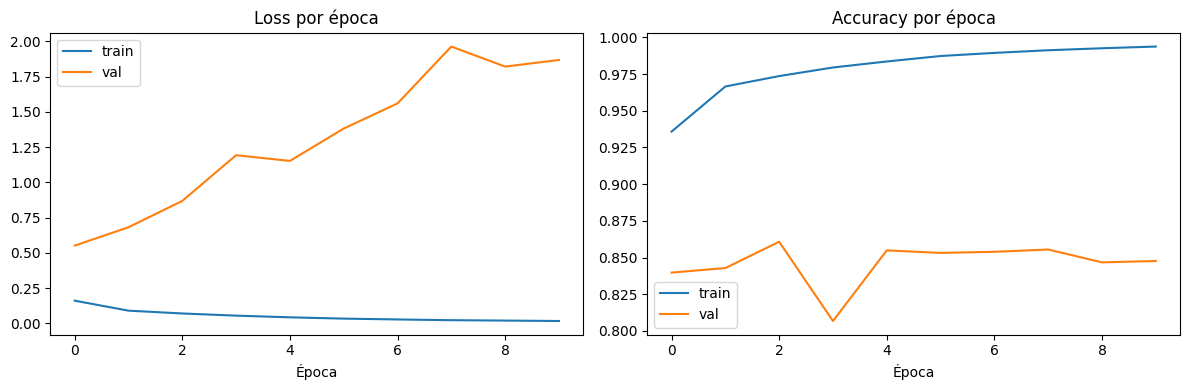

In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'],     label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss por época')
axes[0].set_xlabel('Época')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy por época')
axes[1].set_xlabel('Época')
axes[1].legend()

plt.tight_layout()
plt.show()

2263/2263 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step
=== RELATÓRIO DE CLASSIFICAÇÃO ===
              precision    recall  f1-score   support

      Normal       0.91      0.80      0.85     68774
        AFIB       0.84      0.93      0.88     76030

    accuracy                           0.87    144804
   macro avg       0.87      0.86      0.87    144804
weighted avg       0.87      0.87      0.87    144804

=== MATRIZ DE CONFUSÃO ===


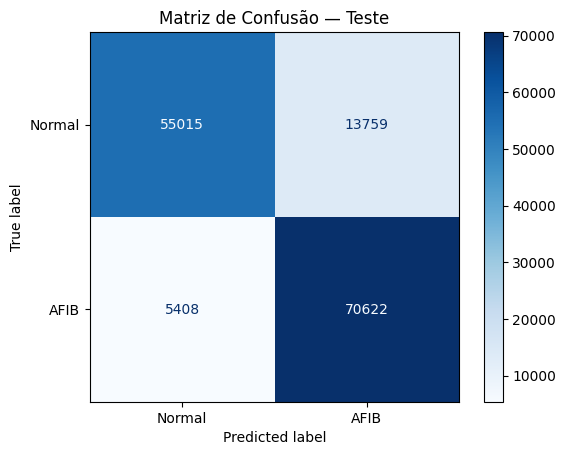

In [26]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_prob = model.predict(X_test, batch_size=64).flatten()
y_pred = (y_prob >= 0.5).astype(int)

print('=== RELATÓRIO DE CLASSIFICAÇÃO ===')
print(classification_report(y_test, y_pred, target_names=['Normal', 'AFIB']))

print('=== MATRIZ DE CONFUSÃO ===')
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'AFIB'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão — Teste')
plt.show()

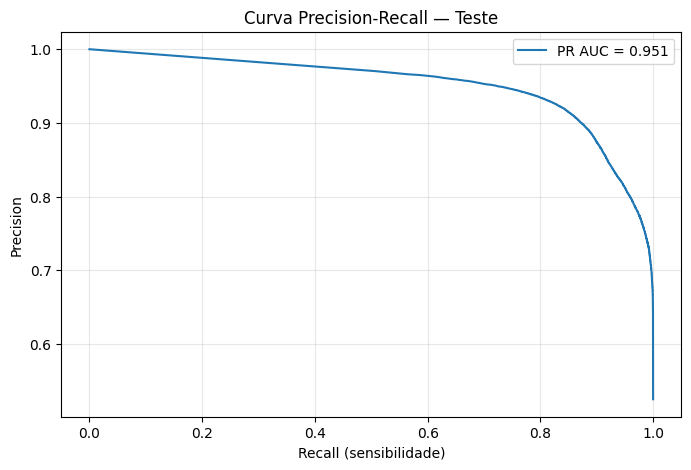

Melhor threshold (precision >= 50%): 0.000
  Recall:    1.000
  Precision: 0.525


In [27]:
from sklearn.metrics import precision_recall_curve, auc

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, label=f'PR AUC = {pr_auc:.3f}')
plt.xlabel('Recall (sensibilidade)')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall — Teste')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Threshold ótimo para maximizar recall com precision aceitável (>= 0.5)
mask = precision >= 0.50
if mask.any():
    best_idx       = np.argmax(recall[:-1][mask[:-1]])
    best_threshold = thresholds[mask[:-1]][best_idx]
    best_recall    = recall[:-1][mask[:-1]][best_idx]
    best_precision = precision[:-1][mask[:-1]][best_idx]
    print(f'Melhor threshold (precision >= 50%): {best_threshold:.3f}')
    print(f'  Recall:    {best_recall:.3f}')
    print(f'  Precision: {best_precision:.3f}')

## 10. Avaliação Final

Depois de treinar os modelos, a avaliação deverá ocorrer em duas camadas:

1. **nível de janela**, que é o problema principal do projeto;
2. **nível de exame**, agregando as predições de todas as janelas de cada registro.

Como o foco declarado do projeto é **não perder AFIB**, a leitura principal dos resultados deve priorizar:

- recall / sensibilidade;
- curva de trade-off com precision;
- comportamento em exames com muitos episódios curtos versus poucos episódios longos.


In [28]:
# ============================================================
# ETAPA 10 — Avaliação comparativa final
# ============================================================

# Próxima implementação sugerida:
# 1. comparar todos os modelos no nível de janela;
# 2. selecionar o melhor trade-off para recall;
# 3. agregar predições por exame;
# 4. discutir vantagens e limitações de cada abordagem;
# 5. preparar tabelas e figuras para o relatório final.

print('Etapa 10 preparada: avaliação final ainda não implementada.')


Etapa 10 preparada: avaliação final ainda não implementada.
